### СЖАТИЕ ПРИЗНАКОВОГО ПРОСТРАНСТВА В ЗАДАЧАХ ОБНАРУЖЕНИЯ НАРУШЕНИЙ ПОЛИТИКИ СЕТЕВОЙ БЕЗОПАСНОСТИ
**Константин Николаевич Осипов**.
г. Москва, assistenttmm@mail.ru
>Аннотация. Интенсивное развитие технологий искусственного интеллекта, включая автономных агентов и большие языковые модели, сопровождается не только позитивными изменениями в IT, но и значительным ростом киберрисков. Наиболее уязвимыми к данным рискам выступают финансовый сектор экономики, а также сегмент транспортной логистики. Традиционные методы обнаружения сетевых атак, основанные на применении методов машинного обучения, сигнатурных методов и гибридных моделей (например, CSSDAE) и демонстрирующие в эксплуатации эмпирическую достоверность обнаружения на уровне более 0,9 по метрике F1-score, сохраняют свою эффективность, как правило, только при условии использовании в централизованных центрах обеспечения политики сетевой безопасности при поддержке человека-оператора. При переносе моделей с централизованных серверов на периферийные устройства в условиях гетерогенных телекоммуникационных сетей, где вычислительные ресурсы узлов ограничены, подобные модели теряют заданные свойства. Одной из ключевых причин падения эффективности моделей является информационная избыточность признакового пространства, которая ведёт к снижению вычислительной производительности и увеличению времени реакции системы. В этой связи в работе предлагается подход к редукции мощности множества параметров, формирующих признаковое пространство. Разработанный метод базируется на двухкаскадной процедуре ранжирования параметров с использованием информационного критерия и теста Гренджера на каузальность. Реализация предложенного подхода в среде имитационного моделирования (на примере набора данных CIRA-CIC-DoHBrw-2020) позволила сократить признаковое пространство более чем на 40% без потери точности обнаружения сетевых атак, что повышает возможность развёртывания моделей на периферийных устройствах с ограниченными вычислительными ресурсами. 
Ключевые слова: информационная безопасность, сжатие признакового пространства, информация, тест Гренджера на каузальность, CIRA-CIC-DoHBrw-2020.

**Ссылка для загрузки набора данных** : https://www.unb.ca/cic/datasets/dohbrw-2020.html

In [1]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from tqdm import tqdm
import time # Импортируем для симуляции долгой работы

In [2]:
import os
files = []
for dirname, _, filenames in os.walk('Total_CSVs'):
    for filename in filenames:
        fp = os.path.join(dirname, filename)
        print(fp)
        files.append(fp)

Total_CSVs\l1-doh.csv
Total_CSVs\l1-nondoh.csv
Total_CSVs\l2-benign.csv
Total_CSVs\l2-malicious.csv


In [3]:
#pip install fastai

*Памятка.*<br> **fastai** — это высокоуровневая библиотека для глубокого обучения, построенная поверх PyTorch . Её главная цель — сделать создание нейронных сетей максимально простым и быстрым, не жертвуя при этом гибкостью и производительностью .
Простыми словами, fastai позволяет решать сложные задачи (например, классификацию изображений или анализ текста) с минимальным количеством кода, используя лучшие современные практики «из коробки» 

Функция df_shrink из модуля fastai.tabular.all автоматически оптимизирует использование памяти pandas DataFrame. Она делает это, изменяя типы данных (dtypes) числовых столбцов на более компактные, но без потери точности .

Для наглядности:

    Целочисленные столбцы (например, int64): могут быть преобразованы в int8, int16 или int32, в зависимости от минимального и максимального значений в столбце.

    Дробные столбцы (например, float64): аналогично могут быть преобразованы в float32.

Это особенно полезно при работе с большими наборами данных, позволяя значительно сократить потребление оперативной памяти и ускорить операции .

In [4]:
from fastai.tabular.all import df_shrink

In [5]:
dfs = [pd.read_csv(f, sep=',', encoding='utf-8') for f in files]
[df.shape for df in dfs]

[(269643, 35), (897493, 35), (19807, 35), (249836, 35)]

In [6]:
dfs[0].columns

Index(['SourceIP', 'DestinationIP', 'SourcePort', 'DestinationPort',
       'TimeStamp', 'Duration', 'FlowBytesSent', 'FlowSentRate',
       'FlowBytesReceived', 'FlowReceivedRate', 'PacketLengthVariance',
       'PacketLengthStandardDeviation', 'PacketLengthMean',
       'PacketLengthMedian', 'PacketLengthMode', 'PacketLengthSkewFromMedian',
       'PacketLengthSkewFromMode', 'PacketLengthCoefficientofVariation',
       'PacketTimeVariance', 'PacketTimeStandardDeviation', 'PacketTimeMean',
       'PacketTimeMedian', 'PacketTimeMode', 'PacketTimeSkewFromMedian',
       'PacketTimeSkewFromMode', 'PacketTimeCoefficientofVariation',
       'ResponseTimeTimeVariance', 'ResponseTimeTimeStandardDeviation',
       'ResponseTimeTimeMean', 'ResponseTimeTimeMedian',
       'ResponseTimeTimeMode', 'ResponseTimeTimeSkewFromMedian',
       'ResponseTimeTimeSkewFromMode',
       'ResponseTimeTimeCoefficientofVariation', 'Label'],
      dtype='object')

In [7]:
#Removing metadata features
for i, df in enumerate(dfs):
    dfs[i] = df.drop(columns=['SourceIP', 'DestinationIP', 'SourcePort', 'DestinationPort', 'TimeStamp'])

In [8]:
#Уменьшение размера
#Отдельные фреймы оптимизируются путем уменьшения размера их типов до
# более подходящих форм, чем типы по умолчанию float64, int64 или object (str).

#Нужен from fastai.tabular.all import df_shrink

for i, df in enumerate(dfs):
    dfs[i] = df_shrink(dfs[i], skip=[], obj2cat=True, int2uint=False)

In [9]:
dfs[0].dtypes

Duration                                   float32
FlowBytesSent                                int32
FlowSentRate                               float32
FlowBytesReceived                            int32
FlowReceivedRate                           float32
PacketLengthVariance                       float32
PacketLengthStandardDeviation              float32
PacketLengthMean                           float32
PacketLengthMedian                         float32
PacketLengthMode                             int16
PacketLengthSkewFromMedian                 float32
PacketLengthSkewFromMode                   float32
PacketLengthCoefficientofVariation         float32
PacketTimeVariance                         float32
PacketTimeStandardDeviation                float32
PacketTimeMean                             float32
PacketTimeMedian                           float32
PacketTimeMode                             float32
PacketTimeSkewFromMedian                   float32
PacketTimeSkewFromMode         

In [10]:
#Removing NaN
for df in dfs:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)    
    print(df.isna().any(axis=1).sum(), "rows with at least one NaN to remove")
    df.dropna(inplace=True)
[df.shape for df in dfs]

344 rows with at least one NaN to remove
7684 rows with at least one NaN to remove
61 rows with at least one NaN to remove
283 rows with at least one NaN to remove


[(269299, 30), (889809, 30), (19746, 30), (249553, 30)]

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Duration,249553.0,55.596367,44.336365,2.100000e-05,33.284267,34.071709,107.294731,1.350884e+02
FlowBytesSent,249553.0,70250.874083,196842.967002,5.600000e+01,1189.000000,1807.000000,26691.000000,8.015359e+06
FlowSentRate,249553.0,1536.531372,61073.285156,2.255432e+00,53.365955,149.655670,1194.134521,2.304348e+07
FlowBytesReceived,249553.0,71741.108390,188404.321892,5.600000e+01,4169.000000,4896.000000,34055.000000,7.723184e+06
FlowReceivedRate,249553.0,2871.527344,22390.201172,2.098855e+00,143.668854,235.529099,1956.398438,7.600000e+06
PacketLengthVariance,249553.0,135854.109375,137194.140625,0.000000e+00,15544.807617,141408.765625,182528.156250,1.338915e+06
PacketLengthStandardDeviation,249553.0,313.073303,194.545059,0.000000e+00,124.678818,376.043579,427.233154,1.157115e+03
PacketLengthMean,249553.0,208.719467,73.680733,5.800000e+01,150.158249,223.433334,248.863632,5.596735e+02
PacketLengthMedian,249553.0,97.045807,43.673386,5.600000e+01,76.000000,76.000000,107.000000,3.170000e+02
PacketLengthMode,249553.0,67.507079,6.236689,5.600000e+01,68.000000,68.000000,68.000000,5.530000e+02


Удаление дубликатов

Дубликатов быть не должно, поскольку они могут искажать результаты обучения и приводить к завышенным оценкам эффективности классификации во время тестирования.

In [12]:
for df in dfs:
    print(df.duplicated().sum(), "fully duplicate rows to remove")
    df.drop_duplicates(inplace=True)
    df.reset_index(inplace=True, drop=True)
[df.shape for df in dfs]

638 fully duplicate rows to remove
139353 fully duplicate rows to remove
623 fully duplicate rows to remove
15 fully duplicate rows to remove


[(268661, 30), (750456, 30), (19123, 30), (249538, 30)]

Parquet - это формат хранения данных, а
 L1-DoH-NonDoH.parquet - это просто имя файла,

In [13]:
pd.concat(objs=[dfs[0], dfs[1]], ignore_index=True, copy=False).to_parquet('L1-DoH-NonDoH.parquet')
pd.concat(objs=[dfs[2], dfs[3]], ignore_index=True, copy=False).to_parquet('L2-BenignDoH-MaliciousDoH.parquet')

In [14]:
df = pd.read_parquet('L1-DoH-NonDoH.parquet')
df.Label.value_counts()



NonDoH    750456
DoH       268661
Name: Label, dtype: int64

In [15]:
df2 = pd.read_parquet('L2-BenignDoH-MaliciousDoH.parquet')
df2.Label.value_counts()

Malicious    249538
Benign        19123
Name: Label, dtype: int64

Для начала работаю с L1 задачей (DoH vs NonDoH), так как:

Классы более сбалансированы

Больше данных для обучения

Это первый уровень детекции

Вот код для подготовки данных и обучения Random Forest:

In [16]:
# Загрузка данных L1
df_l1 = pd.read_parquet('L1-DoH-NonDoH.parquet')

In [17]:
df_l1.head(2)

,Duration,FlowBytesSent,FlowSentRate,FlowBytesReceived,FlowReceivedRate,PacketLengthVariance,PacketLengthStandardDeviation,PacketLengthMean,PacketLengthMedian,PacketLengthMode,...,PacketTimeCoefficientofVariation,ResponseTimeTimeVariance,ResponseTimeTimeStandardDeviation,ResponseTimeTimeMean,ResponseTimeTimeMedian,ResponseTimeTimeMode,ResponseTimeTimeSkewFromMedian,ResponseTimeTimeSkewFromMode,ResponseTimeTimeCoefficientofVariation,Label
0,95.081551,62311,655.342712,65358,687.388855,7474.676758,86.456215,135.673752,102.0,54,...,0.574626,0.001053,0.032457,0.027624,0.026854,0.026822,0.071187,0.024715,1.174948,DoH
1,122.309319,93828,767.136963,101232,827.671997,10458.118164,102.264946,141.245468,114.0,54,...,0.509047,0.001170,0.034200,0.024387,0.021043,0.026981,0.293297,-0.075845,1.402382,DoH


In [18]:
# Кодирование целевой переменной (если еще не закодирована)
le = LabelEncoder()
df_l1['Label_encoded'] = le.fit_transform(df_l1['Label'])

In [19]:
# Разделение на признаки (X) и классы (y)
X = df_l1.drop(['Label', 'Label_encoded'], axis=1)
y = df_l1['Label_encoded']

In [20]:
# Масштабирование признаков (опционально, но Random Forest не требует)
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Сохраняем распределение классов
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение классов в обучающей выборке:\n{y_train.value_counts()}")
print(f"NonDoH (0): {(y_train == 0).sum()/len(y_train)*100:.2f}%")
print(f"DoH (1): {(y_train == 1).sum()/len(y_train)*100:.2f}%")

Размер обучающей выборки: (815293, 29)
Размер тестовой выборки: (203824, 29)

Распределение классов в обучающей выборке:
1    600364
0    214929
Name: Label_encoded, dtype: int64
NonDoH (0): 26.36%
DoH (1): 73.64%


In [21]:
X_train.shape

(815293, 29)

In [22]:
y_train.shape

(815293,)

In [23]:
# 5. Обучение Random Forest с энтропийным критерием
print("\nОбучение Random Forest (criterion='entropy')...")
rf_entropy = RandomForestClassifier(
    n_estimators=100,          # количество деревьев
    criterion='entropy',       # энтропийный подход (информационный выигрыш)
    max_depth=None,            # максимальная глубина
    min_samples_split=2,       # минимальное количество образцов для разделения узла
    min_samples_leaf=1,        # минимальное количество образцов в листе
    random_state=42,
    n_jobs=-1,                 # используем все ядра процессора
    verbose=1                  # показываем прогресс
)

rf_entropy.fit(X_train, y_train)


Обучение Random Forest (criterion='entropy')...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   24.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.2min finished


RandomForestClassifier(criterion='entropy', n_jobs=-1, random_state=42,
                       verbose=1)

In [24]:
# 6. Оценка модели

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


y_pred = rf_entropy.predict(X_test)
y_pred_proba = rf_entropy.predict_proba(X_test)[:, 1]

print("\n=== РЕЗУЛЬТАТЫ ОБУЧЕНИЯ ===")
print(f"Точность на обучающей выборке: {rf_entropy.score(X_train, y_train):.4f}")
print(f"Точность на тестовой выборке: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.



=== РЕЗУЛЬТАТЫ ОБУЧЕНИЯ ===


[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    1.4s finished


Точность на обучающей выборке: 0.9997
Точность на тестовой выборке: 0.9974

Classification Report:
              precision    recall  f1-score   support

         DoH       1.00      0.99      1.00     53732
      NonDoH       1.00      1.00      1.00    150092

    accuracy                           1.00    203824
   macro avg       1.00      1.00      1.00    203824
weighted avg       1.00      1.00      1.00    203824



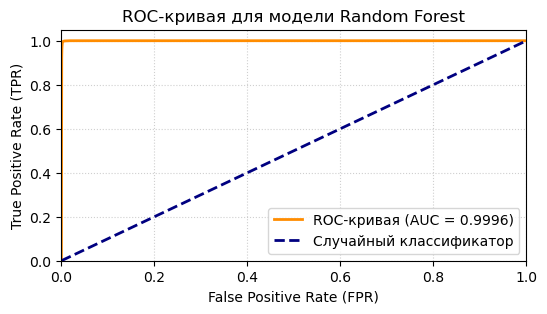

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Вычисляем координаты ROC-кривой и значение AUC
# Внимание: y_test должен содержать бинарные метки (0 и 1)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# 2. Строим график
plt.figure(figsize=(6, 3))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-кривая (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайный классификатор')

# 3. Настраиваем оформление
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая для модели Random Forest')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

# 4. Сохраняем и показываем (используем правильный метод savefig)
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()


=== ТОП-10 ВАЖНЫХ ПРИЗНАКОВ (энтропийный подход) ===
                               feature  importance
                      PacketLengthMode    0.248223
                              Duration    0.082080
                      PacketLengthMean    0.060227
                    PacketLengthMedian    0.058522
                ResponseTimeTimeMedian    0.057836
                        PacketTimeMean    0.053310
                         FlowBytesSent    0.047448
           PacketTimeStandardDeviation    0.038739
         PacketLengthStandardDeviation    0.036039
    PacketLengthCoefficientofVariation    0.033552
                     FlowBytesReceived    0.032062
                    PacketTimeVariance    0.029808
                  PacketLengthVariance    0.027445
              PacketLengthSkewFromMode    0.025323
            PacketLengthSkewFromMedian    0.024443
                      FlowReceivedRate    0.022031
                      PacketTimeMedian    0.021997
                          Fl

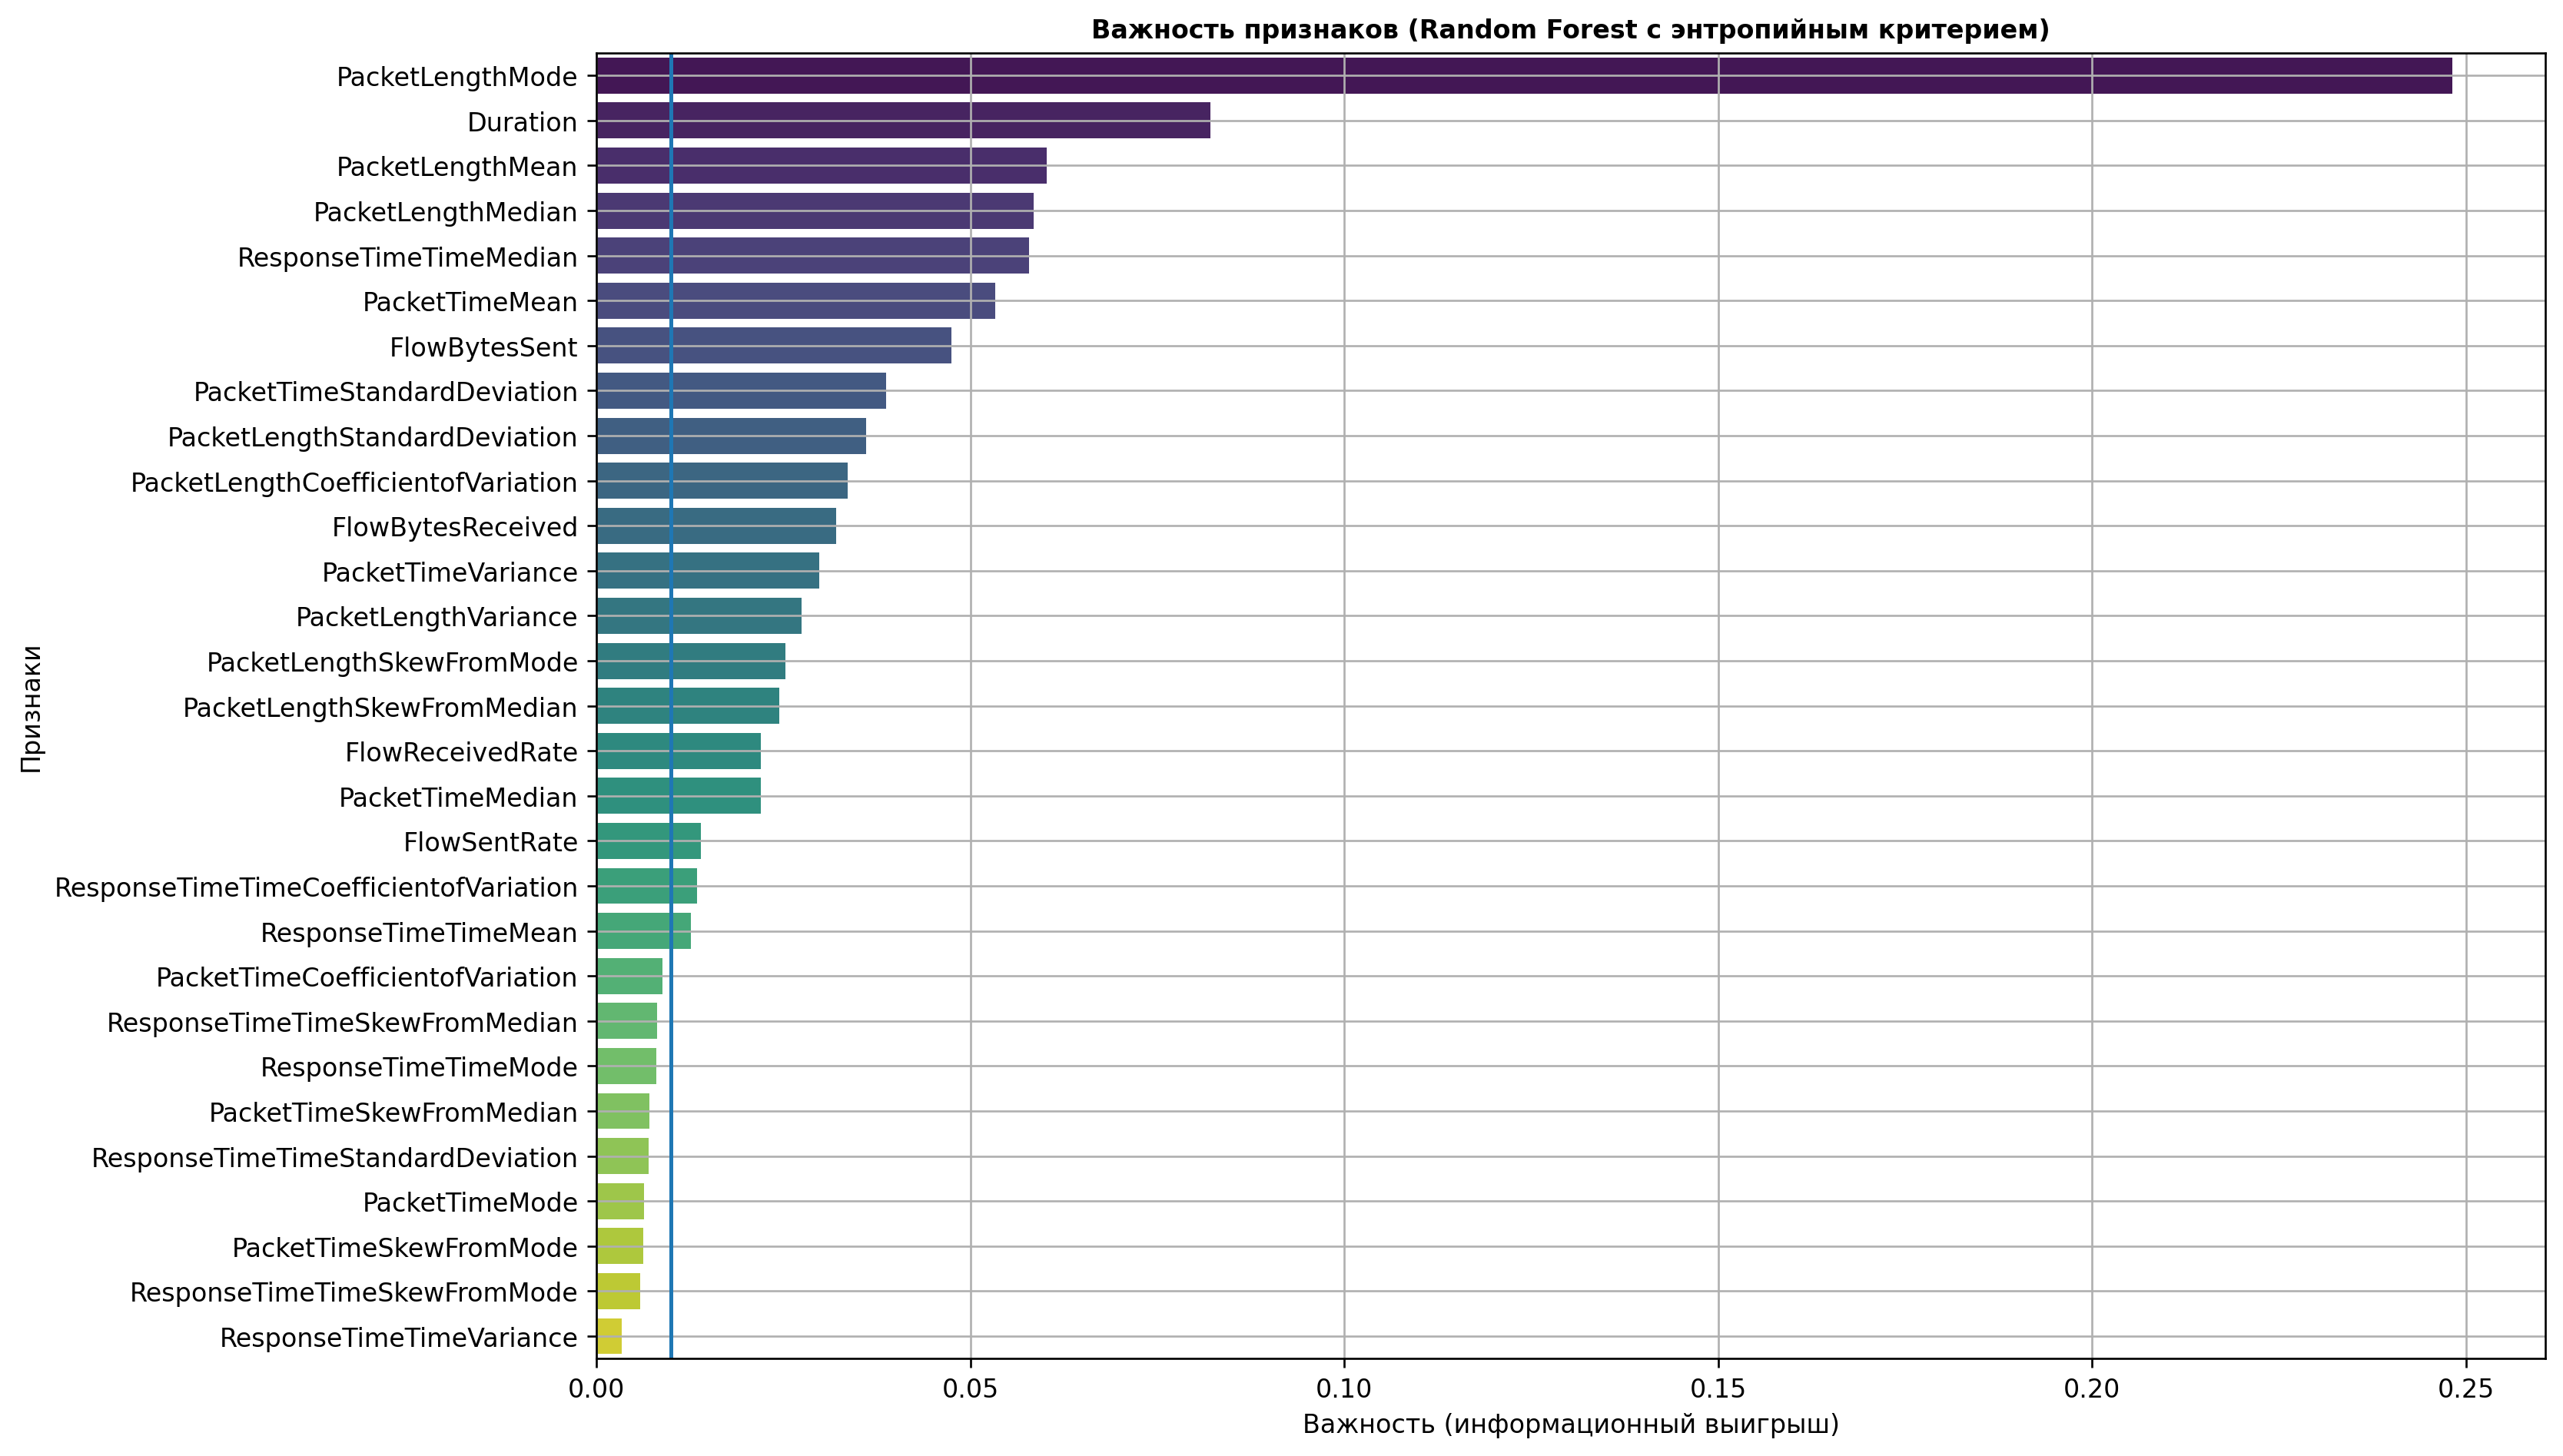

In [26]:
# 7. Получение важности признаков
feature_importance = rf_entropy.feature_importances_
feature_names = X.columns

# Создание DataFrame для удобства
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n=== ТОП-10 ВАЖНЫХ ПРИЗНАКОВ (энтропийный подход) ===")
print(importance_df.head(29).to_string(index=False))

# 8. График важности признаков (вертикальный)
plt.figure(figsize=(14, 8), dpi=240)
sns.barplot(data=importance_df.head(29), x='importance', y='feature', palette='viridis')
plt.title('Важность признаков (Random Forest с энтропийным критерием)', fontsize=10, fontweight='bold')
plt.xlabel('Важность (информационный выигрыш)', fontsize=10)
plt.ylabel('Признаки', fontsize=10)
plt.tight_layout()
plt.axvline(x=0.01)
plt.grid()
plt.show()

In [27]:
import time
from tqdm import tqdm

# === МОДЕЛИРОВАНИЕ ТОЧНОСТИ ДЛЯ РАЗНЫХ НАБОРОВ ПРИЗНАКОВ ===

# Список нужного количества признаков (ваши n пар/переменных)
feature_counts = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]

# Словари для сохранения результатов
results = []

print("\n=== Старт моделирования зависимости точности от количества признаков ===")


# Оборачиваем список в tqdm() для отрисовки статус-бара
for n in tqdm(feature_counts, desc="Тестирование наборов признаков", unit="набор"):
    
    # [Необязательно] Засекаем точное время на один шаг
    start_time = time.time()
    
    # 1. Отбираем топ-N признаков
    top_n_features = importance_df['feature'].head(n).tolist()
    
    # 2. Фильтруем выборки
    X_train_sub = X_train[top_n_features]
    X_test_sub = X_test[top_n_features]
    
    # 3. Обучаем модель (verbose=0 обязателен, чтобы логи RF не ломали tqdm)
    rf_sub = RandomForestClassifier(
        n_estimators=100,
        criterion='entropy',
        random_state=42,
        n_jobs=-1,
        verbose=0 
    )
    rf_sub.fit(X_train_sub, y_train)
    
    # 4. Считаем метрики
    y_pred_sub = rf_sub.predict(X_test_sub)
    acc = accuracy_score(y_test, y_pred_sub)
    
    elapsed_time = time.time() - start_time
    
    # Сохраняем результаты, включая время выполнения шага
    results.append({
        'Количество признаков': n, 
        'Accuracy': acc,
        'Время (сек)': elapsed_time
    })

# Преобразуем в DataFrame
results_df = pd.DataFrame(results)

print("\n=== ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ===")
print(results_df.to_string(index=False))


=== Старт моделирования зависимости точности от количества признаков ===


Тестирование наборов признаков: 100%|███████████████████████████████████████████████| 28/28 [21:49<00:00, 46.78s/набор]


=== ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ===
 Количество признаков  Accuracy  Время (сек)
                    1  0.980748     5.749206
                    2  0.978006    31.281883
                    3  0.992292    19.948345
                    4  0.995221    23.835347
                    5  0.996948    24.749536
                    6  0.996865    28.697101
                    7  0.997203    27.984038
                    8  0.997086    31.363676
                    9  0.997302    39.071376
                   10  0.997316    40.163886
                   11  0.997370    39.649269
                   12  0.997557    41.539545
                   13  0.997567    41.292777
                   14  0.997562    41.620720
                   15  0.997635    42.568958
                   16  0.997537    55.027004
                   17  0.997439    56.217336
                   18  0.997336    57.215886
                   19  0.997410    59.161445
                   20  0.997459    60.368807
                   21  0.

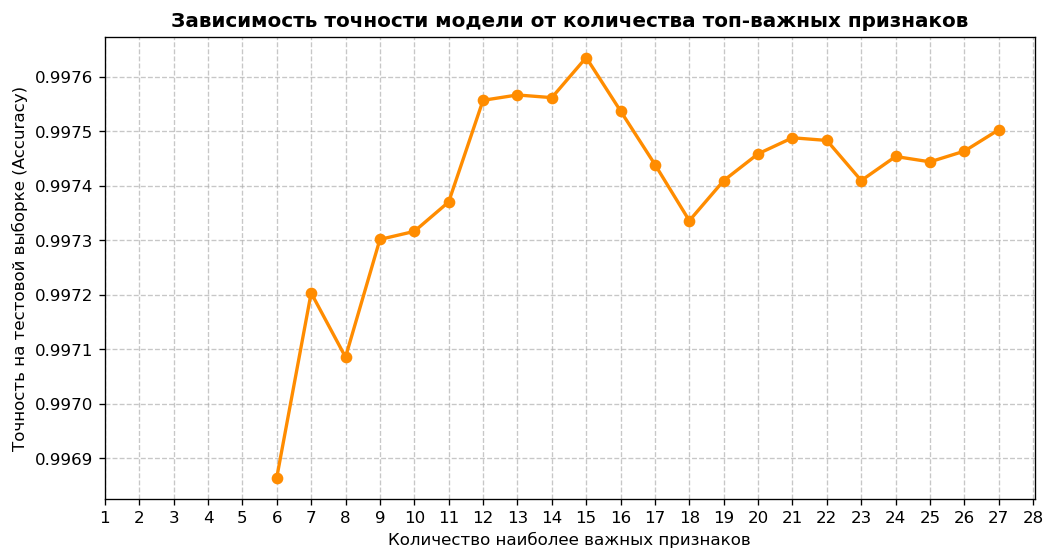

In [28]:
# 10. Визуализация зависимости точности от количества признаков
plt.figure(figsize=(10, 5), dpi=120)
plt.plot(results_df['Количество признаков'][5:-1], results_df['Accuracy'][5:-1], marker='o', linewidth=2, color='darkorange')
plt.title('Зависимость точности модели от количества топ-важных признаков', fontsize=12, fontweight='bold')
plt.xlabel('Количество наиболее важных признаков', fontsize=10)
plt.ylabel('Точность на тестовой выборке (Accuracy)', fontsize=10)
plt.xticks(feature_counts) # Отображаем именно ваши точки на оси X
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().invert_xaxis() # Инвертируем ось X, чтобы идти от 20 к 1 признаку
plt.gca().invert_xaxis()
plt.savefig("output_1.png", dpi=400)
plt.show()

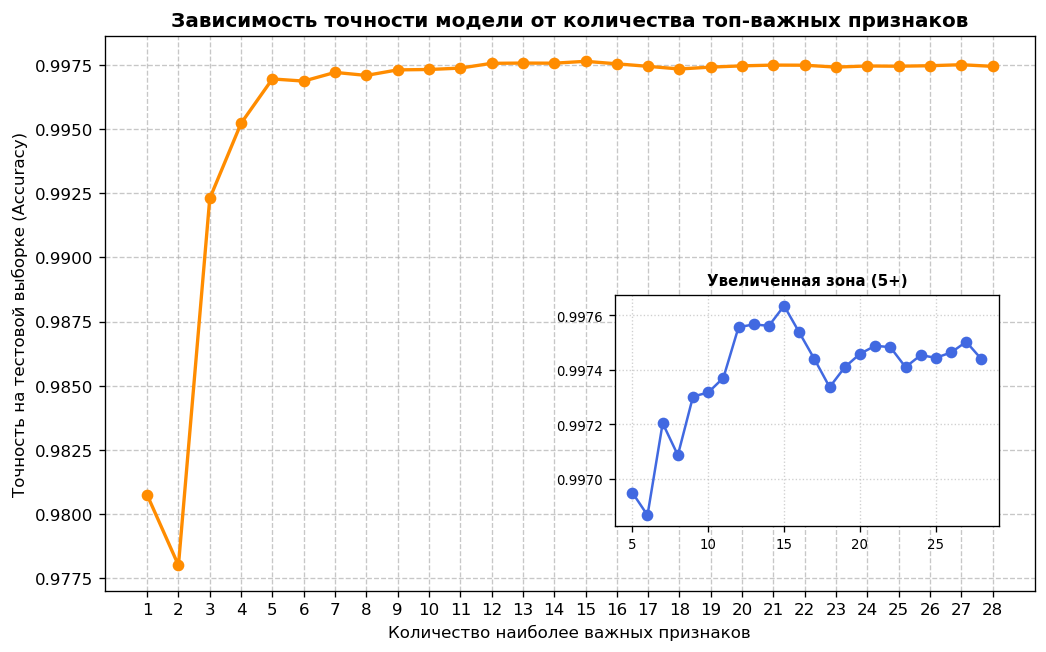

In [29]:
# 10. Визуализация с увеличенным подокном (Inset Axes)
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=120)

# Сортируем данные, чтобы линии не ломались при срезах
plot_df = results_df.sort_values('Количество признаков')

# --- ОСНОВНОЙ ГРАФИК (все точки, например от 1 до 20) ---
ax1.plot(plot_df['Количество признаков'], plot_df['Accuracy'], 
         marker='o', linewidth=2, color='darkorange', label='Вся динамика')
ax1.set_title('Зависимость точности модели от количества топ-важных признаков', fontsize=12, fontweight='bold')
ax1.set_xlabel('Количество наиболее важных признаков', fontsize=10)
ax1.set_ylabel('Точность на тестовой выборке (Accuracy)', fontsize=10)
ax1.set_xticks(feature_counts)
ax1.grid(True, linestyle='--', alpha=0.7)

# --- СОЗДАНИЕ УВЕЛИЧЕННОГО ПОДОКНА ---
# Координаты подокна: [отступ_слева, отступ_снизу, ширина, высота] в процентах от 0 до 1
# Подобрано так, чтобы график встал в свободную зону (например, справа внизу)
ax_inset = plt.axes([0.55, 0.20, 0.32, 0.32]) 

# Срез для подокна (например, только плато высоких значений от 5 до 20 признаков)
sub_df = plot_df[plot_df['Количество признаков'] >= 5]

ax_inset.plot(sub_df['Количество признаков'], sub_df['Accuracy'], 
              marker='o', linewidth=1.5, color='royalblue', label='Зум (5+ признаков)')
ax_inset.set_title('Увеличенная зона (5+)', fontsize=9, fontweight='bold')
ax_inset.grid(True, linestyle=':', alpha=0.6)
ax_inset.tick_params(axis='both', labelsize=8) # Делаем шрифт цифр в подокне меньше
plt.savefig("output_2.png", dpi=400)
plt.show()

In [30]:
from sklearn.metrics import f1_score  # Импортируем метрику F1
import time
from tqdm import tqdm

results = []

print("\n=== Старт моделирования зависимости F1-меры ===")

for n in tqdm(feature_counts, desc="Тестирование наборов признаков", unit="набор"):
    start_time = time.time()
    
    # 1. Отбираем топ-N признаков
    top_n_features = importance_df['feature'].head(n).tolist()
    
    # 2. Фильтруем выборки
    X_train_sub = X_train[top_n_features]
    X_test_sub = X_test[top_n_features]
    
    # 3. Обучаем модель
    rf_sub = RandomForestClassifier(
        n_estimators=100,
        criterion='entropy',
        random_state=42,
        n_jobs=-1,
        verbose=0 
    )
    rf_sub.fit(X_train_sub, y_train)
    
    # 4. Считаем F1-меру (macro-усреднение)
    y_pred_sub = rf_sub.predict(X_test_sub)
    f1 = f1_score(y_test, y_pred_sub, average='macro')  # <--- Заменили accuracy_score
    
    elapsed_time = time.time() - start_time
    
    results.append({
        'Количество признаков': n, 
        'F1-Score': f1,
        'Время (сек)': elapsed_time
    })

results_df = pd.DataFrame(results)

print("\n=== ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ (F1-score) ===")
print(results_df.to_string(index=False))


=== Старт моделирования зависимости F1-меры ===


Тестирование наборов признаков: 100%|███████████████████████████████████████████████| 28/28 [21:52<00:00, 46.88s/набор]


=== ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ (F1-score) ===
 Количество признаков  F1-Score  Время (сек)
                    1  0.974603     5.386374
                    2  0.971645    30.269912
                    3  0.990039    19.995091
                    4  0.993837    23.884184
                    5  0.996066    24.930138
                    6  0.995957    28.675737
                    7  0.996394    27.852160
                    8  0.996241    30.723346
                    9  0.996521    39.672450
                   10  0.996540    40.705106
                   11  0.996610    40.322592
                   12  0.996849    42.254651
                   13  0.996862    41.518421
                   14  0.996855    41.783990
                   15  0.996950    42.609663
                   16  0.996824    55.581113
                   17  0.996698    56.481228
                   18  0.996565    57.286902
                   19  0.996659    59.790707
                   20  0.996723    60.213033
              

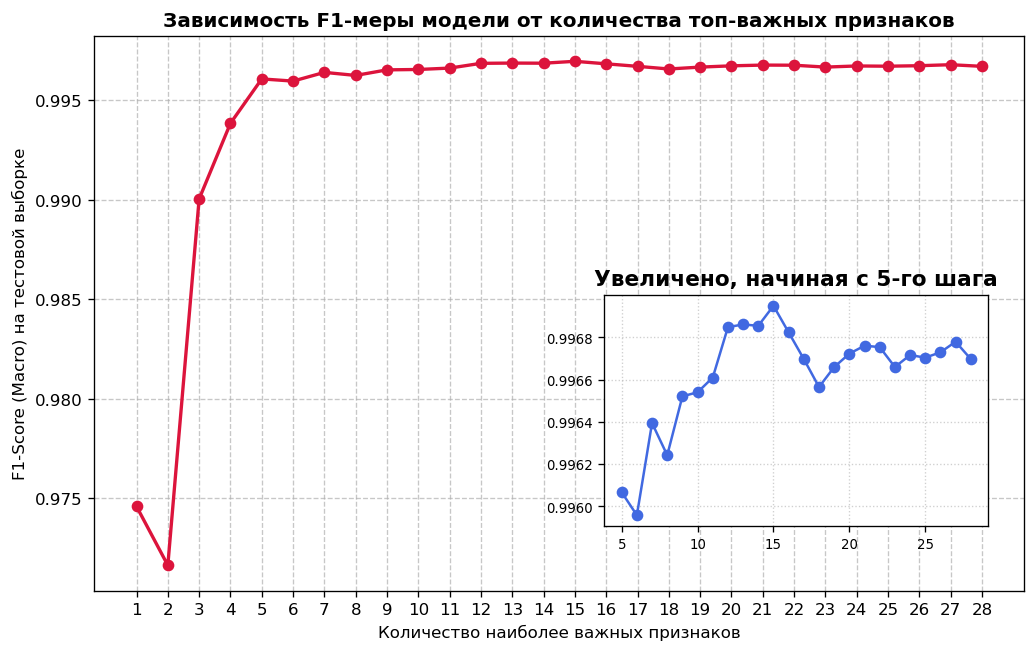

In [31]:
# 10. Визуализация зависимости F1-Score с увеличенным подокном
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=120)

# Сортируем данные по возрастанию признаков
plot_df = results_df.sort_values('Количество признаков')

# --- ОСНОВНОЙ ГРАФИК ---
ax1.plot(plot_df['Количество признаков'], plot_df['F1-Score'], 
         marker='o', linewidth=2, color='crimson', label='Вся динамика F1') # Изменили цвет для отличия
ax1.set_title('Зависимость F1-меры модели от количества топ-важных признаков', fontsize=12, fontweight='bold')
ax1.set_xlabel('Количество наиболее важных признаков', fontsize=10)
ax1.set_ylabel('F1-Score (Macro) на тестовой выборке', fontsize=10)
ax1.set_xticks(feature_counts)
ax1.grid(True, linestyle='--', alpha=0.7)

# --- СОЗДАНИЕ УВЕЛИЧЕННОГО ПОДОКНА ---
# [отступ_слева, отступ_снизу, ширина, высота]
ax_inset = plt.axes([0.55, 0.20, 0.32, 0.32]) 

# Срез для подокна (плато высоких значений от 5 признаков и выше)
sub_df = plot_df[plot_df['Количество признаков'] >= 5]

ax_inset.plot(sub_df['Количество признаков'], sub_df['F1-Score'], 
              marker='o', linewidth=1.5, color='royalblue', label='Зум (5+ признаков)')
ax_inset.set_title('Увеличено, начиная с 5-го шага', fontsize=13, fontweight='bold')
ax_inset.grid(True, linestyle=':', alpha=0.6)
ax_inset.tick_params(axis='both', labelsize=8)
plt.savefig("output_F1.png", dpi=400)
plt.show()

In [32]:
from sklearn.metrics import f1_score, precision_score, recall_score
import time
from tqdm import tqdm

results = []

print("\n=== Старт комплексного моделирования метрик ===")

for n in tqdm(feature_counts, desc="Расчет всех метрик", unit="набор"):
    start_time = time.time()
    
    # 1. Отбираем топ-N признаков
    top_n_features = importance_df['feature'].head(n).tolist()
    
    # 2. Фильтруем выборки
    X_train_sub = X_train[top_n_features]
    X_test_sub = X_test[top_n_features]
    
    # 3. Обучаем модель
    rf_sub = RandomForestClassifier(
        n_estimators=100,
        criterion='entropy',
        random_state=42,
        n_jobs=-1,
        verbose=0 
    )
    rf_sub.fit(X_train_sub, y_train)
    y_pred_sub = rf_sub.predict(X_test_sub)
    
    # 4. Расчет комплекса полезных мер (используем macro для баланса классов)
    acc = accuracy_score(y_test, y_pred_sub)
    f1 = f1_score(y_test, y_pred_sub, average='macro')
    precision = precision_score(y_test, y_pred_sub, average='macro')
    recall = recall_score(y_test, y_pred_sub, average='macro')
    
    elapsed_time = time.time() - start_time
    
    results.append({
        'Количество признаков': n, 
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall,
        'Время (сек)': elapsed_time
    })

results_df = pd.DataFrame(results)

print("\n=== СВОДНАЯ ТАБЛИЦА ВСЕХ МЕТРИК ===")
print(results_df.round(4).to_string(index=False))





=== Старт комплексного моделирования метрик ===


Расчет всех метрик: 100%|███████████████████████████████████████████████████████████| 28/28 [21:57<00:00, 47.06s/набор]


=== СВОДНАЯ ТАБЛИЦА ВСЕХ МЕТРИК ===
 Количество признаков  Accuracy  F1-Score  Precision  Recall  Время (сек)
                    1    0.9807    0.9746     0.9872  0.9636       5.4749
                    2    0.9780    0.9716     0.9721  0.9711      30.4976
                    3    0.9923    0.9900     0.9918  0.9883      20.1811
                    4    0.9952    0.9938     0.9945  0.9932      24.1571
                    5    0.9969    0.9961     0.9966  0.9956      25.1416
                    6    0.9969    0.9960     0.9967  0.9953      29.4905
                    7    0.9972    0.9964     0.9970  0.9958      27.9103
                    8    0.9971    0.9962     0.9970  0.9955      30.9211
                    9    0.9973    0.9965     0.9971  0.9959      39.9116
                   10    0.9973    0.9965     0.9971  0.9960      40.8047
                   11    0.9974    0.9966     0.9971  0.9961      40.0036
                   12    0.9976    0.9968     0.9976  0.9961      42.2149
 

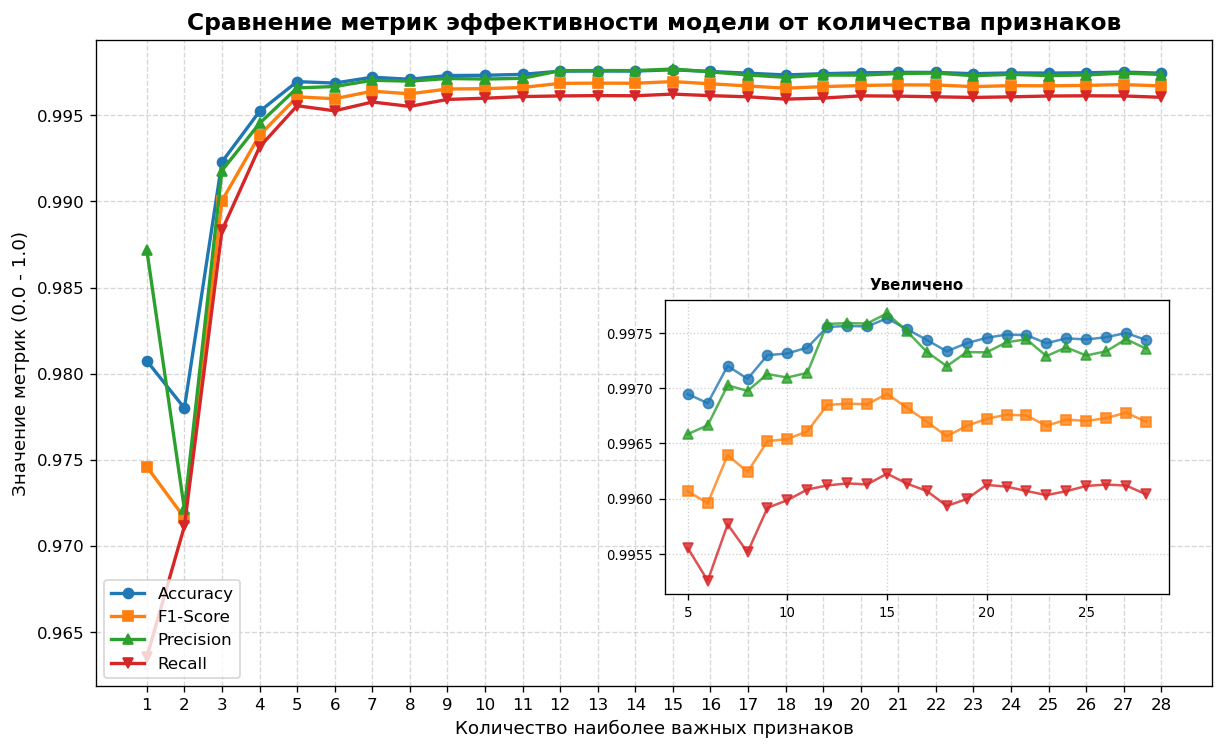

In [33]:
# Сортируем для корректного отображения линий слева направо
plot_df = results_df.sort_values('Количество признаков')

# Создаем общее окно
fig, ax1 = plt.subplots(figsize=(12, 7), dpi=120)

# Список метрик для автоматизации построения линий
metrics = {
    'Accuracy': ('#1f77b4', 'o'),
    'F1-Score': ('#ff7f0e', 's'),
    'Precision': ('#2ca02c', '^'),
    'Recall': ('#d62728', 'v')
}

# --- ОСНОВНОЙ ГРАФИК ---
for metric, (color, marker) in metrics.items():
    ax1.plot(plot_df['Количество признаков'], plot_df[metric], 
             marker=marker, linewidth=2, color=color, label=metric)

ax1.set_title('Сравнение метрик эффективности модели от количества признаков', fontsize=14, fontweight='bold')
ax1.set_xlabel('Количество наиболее важных признаков', fontsize=11)
ax1.set_ylabel('Значение метрик (0.0 - 1.0)', fontsize=11)
ax1.set_xticks(feature_counts)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower left', fontsize=10) # Легенда в левом нижнем углу, чтобы не мешать плато

# --- УВЕЛИЧЕННОЕ ПОДОКНО (ПЛАТО ВЫСОКИХ ЗНАЧЕНИЙ) ---
# Смещаем чуть выше центра [отступ_слева, отступ_снизу, ширина, высота]
ax_inset = plt.axes([0.52, 0.22, 0.35, 0.35]) 

# Берем стабильную зону (от 5 признаков и выше)
sub_df = plot_df[plot_df['Количество признаков'] >= 5]

for metric, (color, marker) in metrics.items():
    ax_inset.plot(sub_df['Количество признаков'], sub_df[metric], 
                 marker=marker, linewidth=1.5, color=color, alpha=0.8)

ax_inset.set_title('Увеличено', fontsize=9, fontweight='bold')
ax_inset.grid(True, linestyle=':', alpha=0.6)
ax_inset.tick_params(axis='both', labelsize=8)
plt.savefig("output_F1_summ.png", dpi=400)
plt.show()

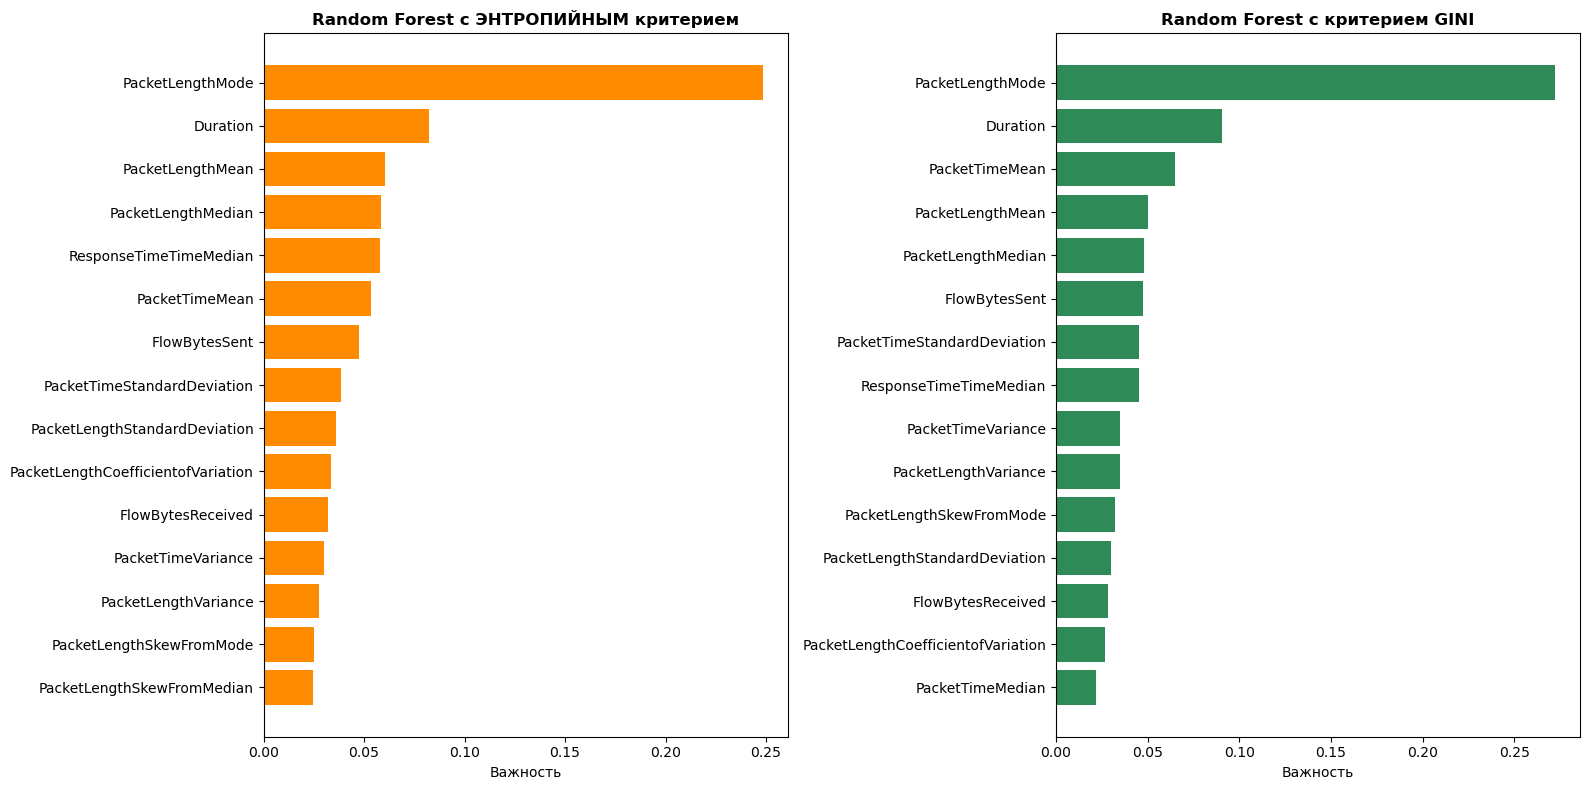


Корреляция Спирмена между важностями (Entropy vs Gini): 0.9611
p-value: 1.2993e-16


In [34]:
# Сравнение энтропии vs Gini
rf_gini = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',  # критерий Джини для сравнения
    random_state=42,
    n_jobs=-1
)

rf_gini.fit(X_train, y_train)

# Сравнение важности признаков
importance_gini = rf_gini.feature_importances_

# График сравнения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Энтропия
top_entropy = importance_df.head(15)
ax1.barh(range(len(top_entropy)), top_entropy['importance'].values, color='darkorange')
ax1.set_yticks(range(len(top_entropy)))
ax1.set_yticklabels(top_entropy['feature'].values)
ax1.set_xlabel('Важность')
ax1.set_title('Random Forest с ЭНТРОПИЙНЫМ критерием', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# Gini
gini_df = pd.DataFrame({'feature': feature_names, 'importance': importance_gini})
gini_df = gini_df.sort_values('importance', ascending=False).head(15)
ax2.barh(range(len(gini_df)), gini_df['importance'].values, color='seagreen')
ax2.set_yticks(range(len(gini_df)))
ax2.set_yticklabels(gini_df['feature'].values)
ax2.set_xlabel('Важность')
ax2.set_title('Random Forest с критерием GINI', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
plt.savefig("output_5.png", dpi=400)
plt.tight_layout()
plt.show()

# Корреляция между оценками важности
from scipy.stats import spearmanr

correlation, p_value = spearmanr(feature_importance, importance_gini)
print(f"\nКорреляция Спирмена между важностями (Entropy vs Gini): {correlation:.4f}")
print(f"p-value: {p_value:.4e}")

## 2.1 KL-дивергенция для ранжирования признаков в форме Джеффириса

Для двух непрерывных распределений вероятностей 
P иQ с функциями плотности p(x) и q(x):

markdown
$$ D_J(P \parallel Q) = \frac{1}{2} \int \left( p(x) - q(x) \right) \ln \left( \frac{p(x)}{q(x)} \right) dx $$

Формула (дискретный случай)
Для двух дискретных распределений 
P = (p1,…,pn) и Q=(q1,…,qn):

markdown
$$ D_J(P \parallel Q) = \frac{1}{2} \sum_{i=1}^n \left( p_i - q_i \right) \ln \left( \frac{p_i}{q_i} \right) $$

Дивергенция Джеффриса часто определяется как симметричная версия дивергенции Кульбака–Лейбнера:

$$ D_J(P \parallel Q) = \frac{1}{2} \left[ D_{KL}(P \parallel Q) + D_{KL}(Q \parallel P) \right] = \frac{1}{2} \sum_i (p_i - q_i) \ln \frac{p_i}{q_i} $$

В параметрическом виде дивергенция Джеффриса записывается через интеграл по пространству параметров (например, $\theta$), особенно в контексте байесовского вывода или информационной геометрии, где сравниваются два распределения из одного параметрического семейства $p(x \mid \theta)$.

Классическое определение использует распределения $p(x \mid \theta_1)$ и $p(x \mid \theta_2)$.

 Непрерывный параметрический случай

$$ D_J(\theta_1 \parallel \theta_2) = \frac{1}{2} \int \left( p(x \mid \theta_1) - p(x \mid \theta_2) \right) \ln \left( \frac{p(x \mid \theta_1)}{p(x \mid \theta_2)} \right) dx $$

Или эквивалентно через сумму дивергенций Кульбака–Лейблера:

$$ D_J(\theta_1, \theta_2) = \frac{1}{2} \left[ D_{KL}(p(x \mid \theta_1) \parallel p(x \mid \theta_2)) + D_{KL}(p(x \mid \theta_2) \parallel p(x \mid \theta_1)) \right] $$

Дискретный параметрический случай

Если пространство $x$ дискретно:

$$ D_J(\theta_1, \theta_2) = \frac{1}{2} \sum_{i} \left( p(x_i \mid \theta_1) - p(x_i \mid \theta_2) \right) \ln \left( \frac{p(x_i \mid \theta_1)}{p(x_i \mid \theta_2)} \right) $$

Для экспоненциального семейства (пример)

Если $p(x \mid \theta) = h(x) \exp\left( \theta \cdot T(x) - A(\theta) \right)$, то дивергенция Джеффриса между $\theta_1$ и $\theta_2$ выражается через разность потенциалов $A(\theta)$:

$$ D_J(\theta_1, \theta_2) = \frac{1}{2} \left[ (\theta_1 - \theta_2) \cdot ( \nabla A(\theta_1) - \nabla A(\theta_2) ) \right] $$

Этот вариант особенно полезен в информационной геометрии, где $D_J$ связана с квадратом римановой метрики Фишера для бесконечно близких $\theta_1$ и $\theta_2$.

## 2.2 Дивергенция Джеффриса для двух одномерных нормальных распределений

Частный случай параметрической дивергенции Джеффриса, когда оба распределения $p(x \mid \theta_1)$ и $p(x \mid \theta_2)$ являются **нормальными (гауссовскими)** с параметрами:

- Для класса 0: $\mathcal{N}(\mu_0, \sigma_0^2)$, где $\mu_0$ = `means_0`, $\sigma_0^2$ = `vars_0`
- Для класса 1: $\mathcal{N}(\mu_1, \sigma_1^2)$, где $\mu_1$ = `means_1`, $\sigma_1^2$ = `vars_1`

### Аналитическая формула

Для двух одномерных нормальных распределений дивергенция Джеффриса имеет замкнутую форму:

$$ D_J(\mathcal{N}_0 \parallel \mathcal{N}_1) = \frac{1}{2} \left[ \frac{(\mu_0 - \mu_1)^2}{\sigma_1^2} + \frac{(\mu_0 - \mu_1)^2}{\sigma_0^2} \right] + \frac{1}{2} \left[ \frac{\sigma_0^2}{\sigma_1^2} + \frac{\sigma_1^2}{\sigma_0^2} - 2 \right] $$

### 2.3. Многомерное нормальное распределение (общий случай)

Пусть $P = \mathcal{N}_d(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)$ и $Q = \mathcal{N}_d(\boldsymbol{\mu}_2, \boldsymbol{\Sigma}_2)$, где:
- $\boldsymbol{\mu}_1, \boldsymbol{\mu}_2 \in \mathbb{R}^d$ — векторы средних
- $\boldsymbol{\Sigma}_1, \boldsymbol{\Sigma}_2 \in \mathbb{R}^{d \times d}$ — ковариационные матрицы (положительно определённые)

Тогда дивергенция Джеффриса вычисляется по формуле:

$$ D_J(\mathcal{N}_1 \parallel \mathcal{N}_2) = \frac{1}{4} (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)^T \left( \boldsymbol{\Sigma}_1^{-1} + \boldsymbol{\Sigma}_2^{-1} \right) (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2) + \frac{1}{2} \left[ \frac{\det(\boldsymbol{\Sigma}_1)}{\det(\boldsymbol{\Sigma}_2)} + \frac{\det(\boldsymbol{\Sigma}_2)}{\det(\boldsymbol{\Sigma}_1)} - 2 \right] $$

**Упрощённая форма** (через след матрицы):

$$ D_J = \frac{1}{2} (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)^T \boldsymbol{\Sigma}_{12}^{-1} (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2) + \frac{1}{4} \operatorname{tr} \left( \boldsymbol{\Sigma}_1^{-1} \boldsymbol{\Sigma}_2 + \boldsymbol{\Sigma}_2^{-1} \boldsymbol{\Sigma}_1 - 2 \mathbf{I} \right) $$

где $\boldsymbol{\Sigma}_{12}^{-1} = \frac{1}{2} (\boldsymbol{\Sigma}_1^{-1} + \boldsymbol{\Sigma}_2^{-1})$.

### 2.4. Частный случай: диагональные ковариационные матрицы (независимые признаки)

Если признаки некоррелированы, то $\boldsymbol{\Sigma}_1 = \operatorname{diag}(\sigma_{1,1}^2, \dots, \sigma_{1,d}^2)$ и $\boldsymbol{\Sigma}_2 = \operatorname{diag}(\sigma_{2,1}^2, \dots, \sigma_{2,d}^2)$. Тогда дивергенция распадается на сумму по каждому признаку:

$$ D_J = \sum_{i=1}^d \left[ \frac{(\mu_{1,i} - \mu_{2,i})^2}{2} \left( \frac{1}{\sigma_{1,i}^2} + \frac{1}{\sigma_{2,i}^2} \right) + \frac{1}{2} \left( \frac{\sigma_{1,i}^2}{\sigma_{2,i}^2} + \frac{\sigma_{2,i}^2}{\sigma_{1,i}^2} - 2 \right) \right] $$

Это в точности то, что реализовано в вашем коде (попризнаковое суммирование).

### 2.5. Обобщение для экспоненциального семейства

Для любого распределения из экспоненциального семейства:

$$ p(x \mid \boldsymbol{\theta}) = h(x) \exp\left( \boldsymbol{\theta}^T \mathbf{T}(x) - A(\boldsymbol{\theta}) \right) $$

дивергенция Джеффриса между параметрами $\boldsymbol{\theta}_1$ и $\boldsymbol{\theta}_2$:

$$ D_J(\boldsymbol{\theta}_1, \boldsymbol{\theta}_2) = \frac{1}{2} (\boldsymbol{\theta}_1 - \boldsymbol{\theta}_2)^T \left( \nabla A(\boldsymbol{\theta}_1) - \nabla A(\boldsymbol{\theta}_2) \right) $$

### 2.6. Связь с метрикой Фишера

Для бесконечно близких распределений ($\boldsymbol{\theta}_2 = \boldsymbol{\theta}_1 + d\boldsymbol{\theta}$) дивергенция Джеффриса приближается к квадрату римановой метрики Фишера:

$$ D_J(\boldsymbol{\theta}, \boldsymbol{\theta} + d\boldsymbol{\theta}) \approx \frac{1}{2} d\boldsymbol{\theta}^T \mathbf{I}_F(\boldsymbol{\theta}) \, d\boldsymbol{\theta} $$

где $\mathbf{I}_F(\boldsymbol{\theta})$ — матрица информации Фишера.

In [35]:
# Создаем таблицу, где только класс 0 (NonDoH)
X_train_class_0 = X_train[y_train == 0]
y_train_class_0 = y_train[y_train == 0]

# Создаем таблицу, где только класс 1 (DoH)
X_train_class_1 = X_train[y_train == 1]
y_train_class_1 = y_train[y_train == 1]

# Выводим новые размеры таблиц для проверки
print(f"Размер таблицы класса 0 (NonDoH): {X_train_class_0.shape}")
print(f"Размер таблицы класса 1 (DoH): {X_train_class_1.shape}")

Размер таблицы класса 0 (NonDoH): (214929, 29)
Размер таблицы класса 1 (DoH): (600364, 29)


In [36]:
# 1. Считаем среднее (mean) и дисперсию (var) для каждой таблицы отдельно
means_0 = X_train_class_0.mean()
vars_0 = X_train_class_0.var()

means_1 = X_train_class_1.mean()
vars_1 = X_train_class_1.var()

# Добавляем небольшую константу (эпсилон) во избежание деления на ноль, 
# если вдруг у какого-то признака нулевая дисперсия
eps = 1e-9
vars_0 = vars_0 + eps
vars_1 = vars_1 + eps

# 2. Вычисляем дивергенцию Джеффриса по формуле для каждого признака
term_means = ((means_0 - means_1) ** 2) / 2 * (1 / vars_0 + 1 / vars_1)
term_vars = 0.5 * (vars_0 / vars_1 + vars_1 / vars_0 - 2)
jeffreys_div = term_means + term_vars

# 3. Оформляем результат в красивый датафрейм
jd_df = pd.DataFrame({
    'Feature': X_train_class_0.columns,
    'Jeffreys_Divergence': jeffreys_div
}).sort_values(by='Jeffreys_Divergence', ascending=False).reset_index(drop=True)

# Смотрим топ-10 самых информативных параметров
print("Топ-10 параметров по дивергенции Джеффриса:")
print(jd_df.head(29))

Топ-10 параметров по дивергенции Джеффриса:
                                   Feature  Jeffreys_Divergence
0                         PacketLengthMode          1284.534044
1                     PacketLengthVariance            47.435150
2                       PacketLengthMedian            31.657513
3                         PacketLengthMean            11.522165
4                   ResponseTimeTimeMedian            11.459438
5                     ResponseTimeTimeMode            10.495820
6                            FlowBytesSent            10.334157
7                         FlowReceivedRate             8.013913
8             ResponseTimeTimeSkewFromMode             5.193237
9                     ResponseTimeTimeMean             5.163769
10                          PacketTimeMean             4.343873
11                        PacketTimeMedian             4.221400
12                          PacketTimeMode             3.165624
13                            FlowSentRate             3.095

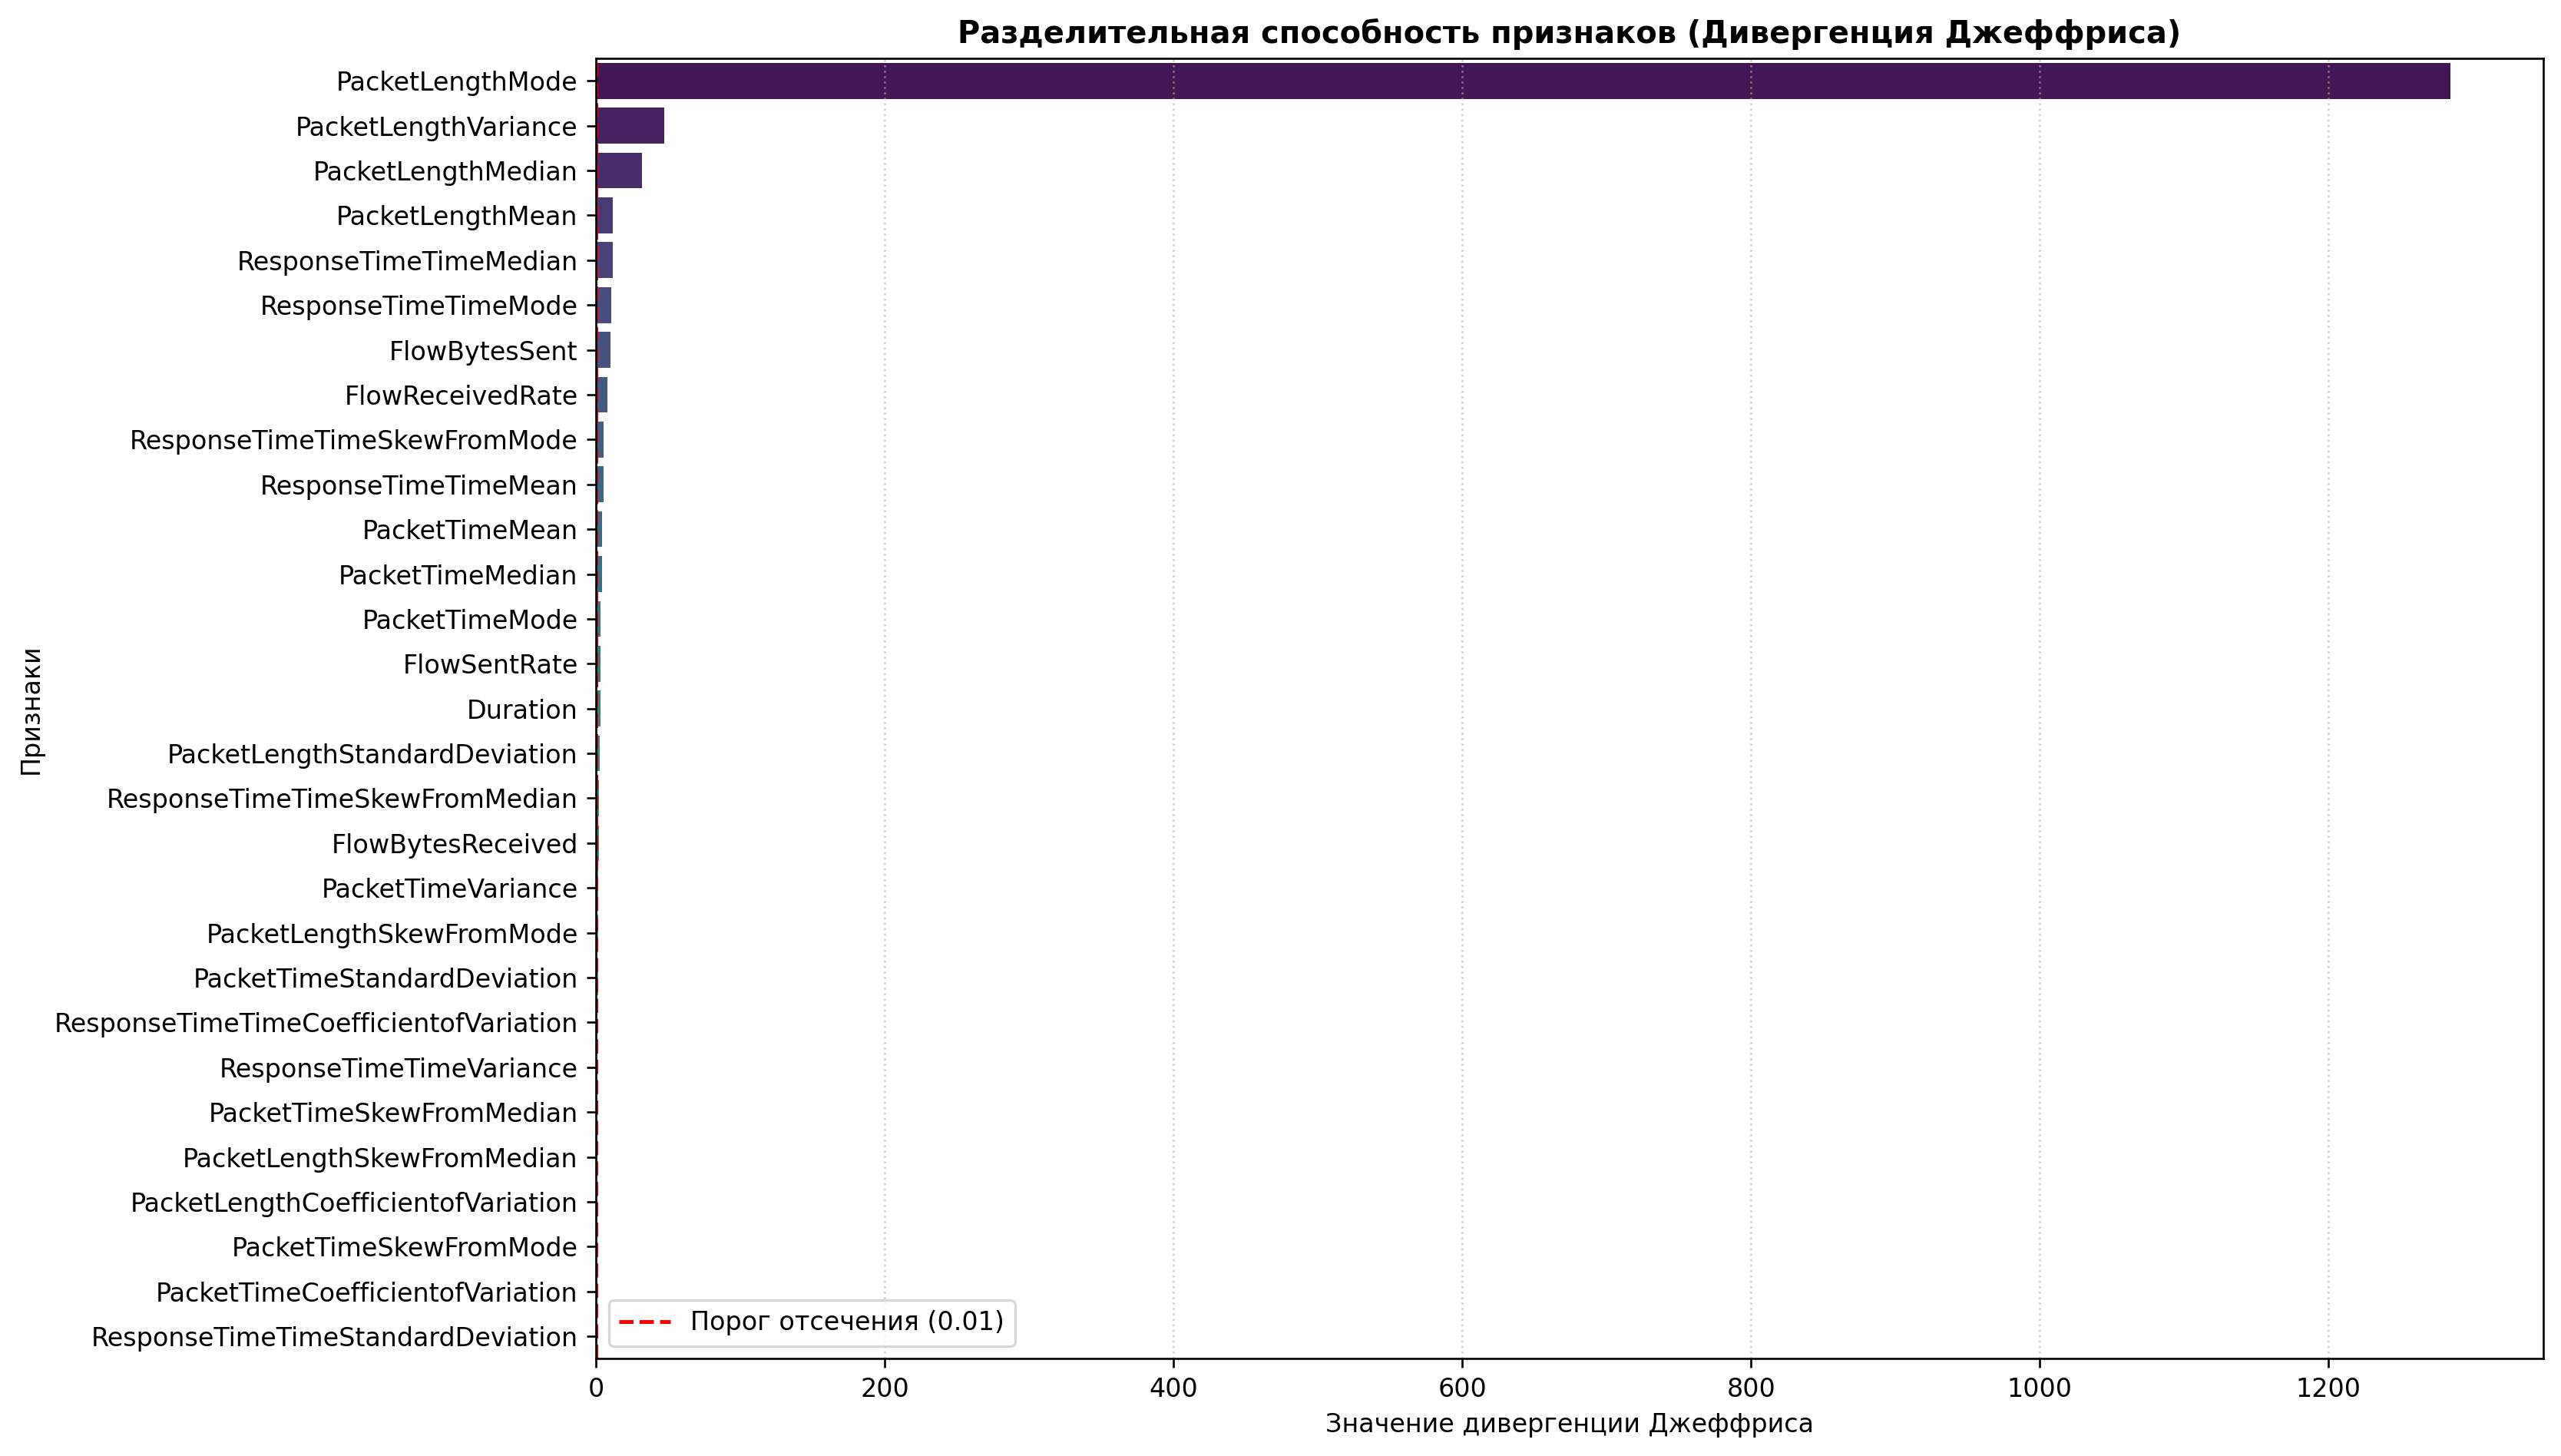

In [37]:
# График дивергенции Джеффриса для признаков (вертикальный)
plt.figure(figsize=(14, 8), dpi=240)

# ИССПРАВЛЕНО: x='Jeffreys_Divergence' и y='Feature' (соответствует именам в jd_df)
sns.barplot(data=jd_df.head(29), x='Jeffreys_Divergence', y='Feature', palette='viridis')

# ИСПРАВЛЕНО: Изменено название на Джеффриса
plt.title('Разделительная способность признаков (Дивергенция Джеффриса)', fontsize=12, fontweight='bold')

# ИСПРАВЛЕНО: Изменена подпись оси X
plt.xlabel('Значение дивергенции Джеффриса', fontsize=10)
plt.ylabel('Признаки', fontsize=10)

plt.axvline(x=0.01, color='red', linestyle='--', label='Порог отсечения (0.01)') # Добавили цвет для наглядности порога
plt.legend()
plt.tight_layout()
plt.grid(axis='x', linestyle=':', alpha=0.6) # Сетка только по вертикали для лучшей читаемости
plt.savefig("output_6.png", dpi=400)
plt.show()

## Нормализация дивергенции Джеффриса

### Формула

$$ D_J^{\text{norm}}(f_i) = \frac{D_J(f_i)}{\max\limits_{j} D_J(f_j)} $$

где $D_J(f_i)$ — исходная дивергенция Джеффриса для признака $f_i$.

### Свойства

- **Сохранение порядка**: признаки сохраняют ту же сортировку по информативности

- **Интерпретируемость**: значение $1$ означает наиболее информативный признак, значение $0$ — наименее информативный

- **Масштаб**: не зависит от абсолютных величин дивергенции, удобно для сравнения разных наборов признаков

In [38]:
jd_df_norm = jd_df.copy()
jd_df_norm.loc[:, 'Jeffreys_Divergence'] = jd_df['Jeffreys_Divergence'] / jd_df['Jeffreys_Divergence'].max()
jd_df_norm

,Feature,Jeffreys_Divergence
0,PacketLengthMode,1.000000
1,PacketLengthVariance,0.036928
2,PacketLengthMedian,0.024645
3,PacketLengthMean,0.008970
4,ResponseTimeTimeMedian,0.008921
5,ResponseTimeTimeMode,0.008171
6,FlowBytesSent,0.008045
7,FlowReceivedRate,0.006239
8,ResponseTimeTimeSkewFromMode,0.004043
9,ResponseTimeTimeMean,0.004020


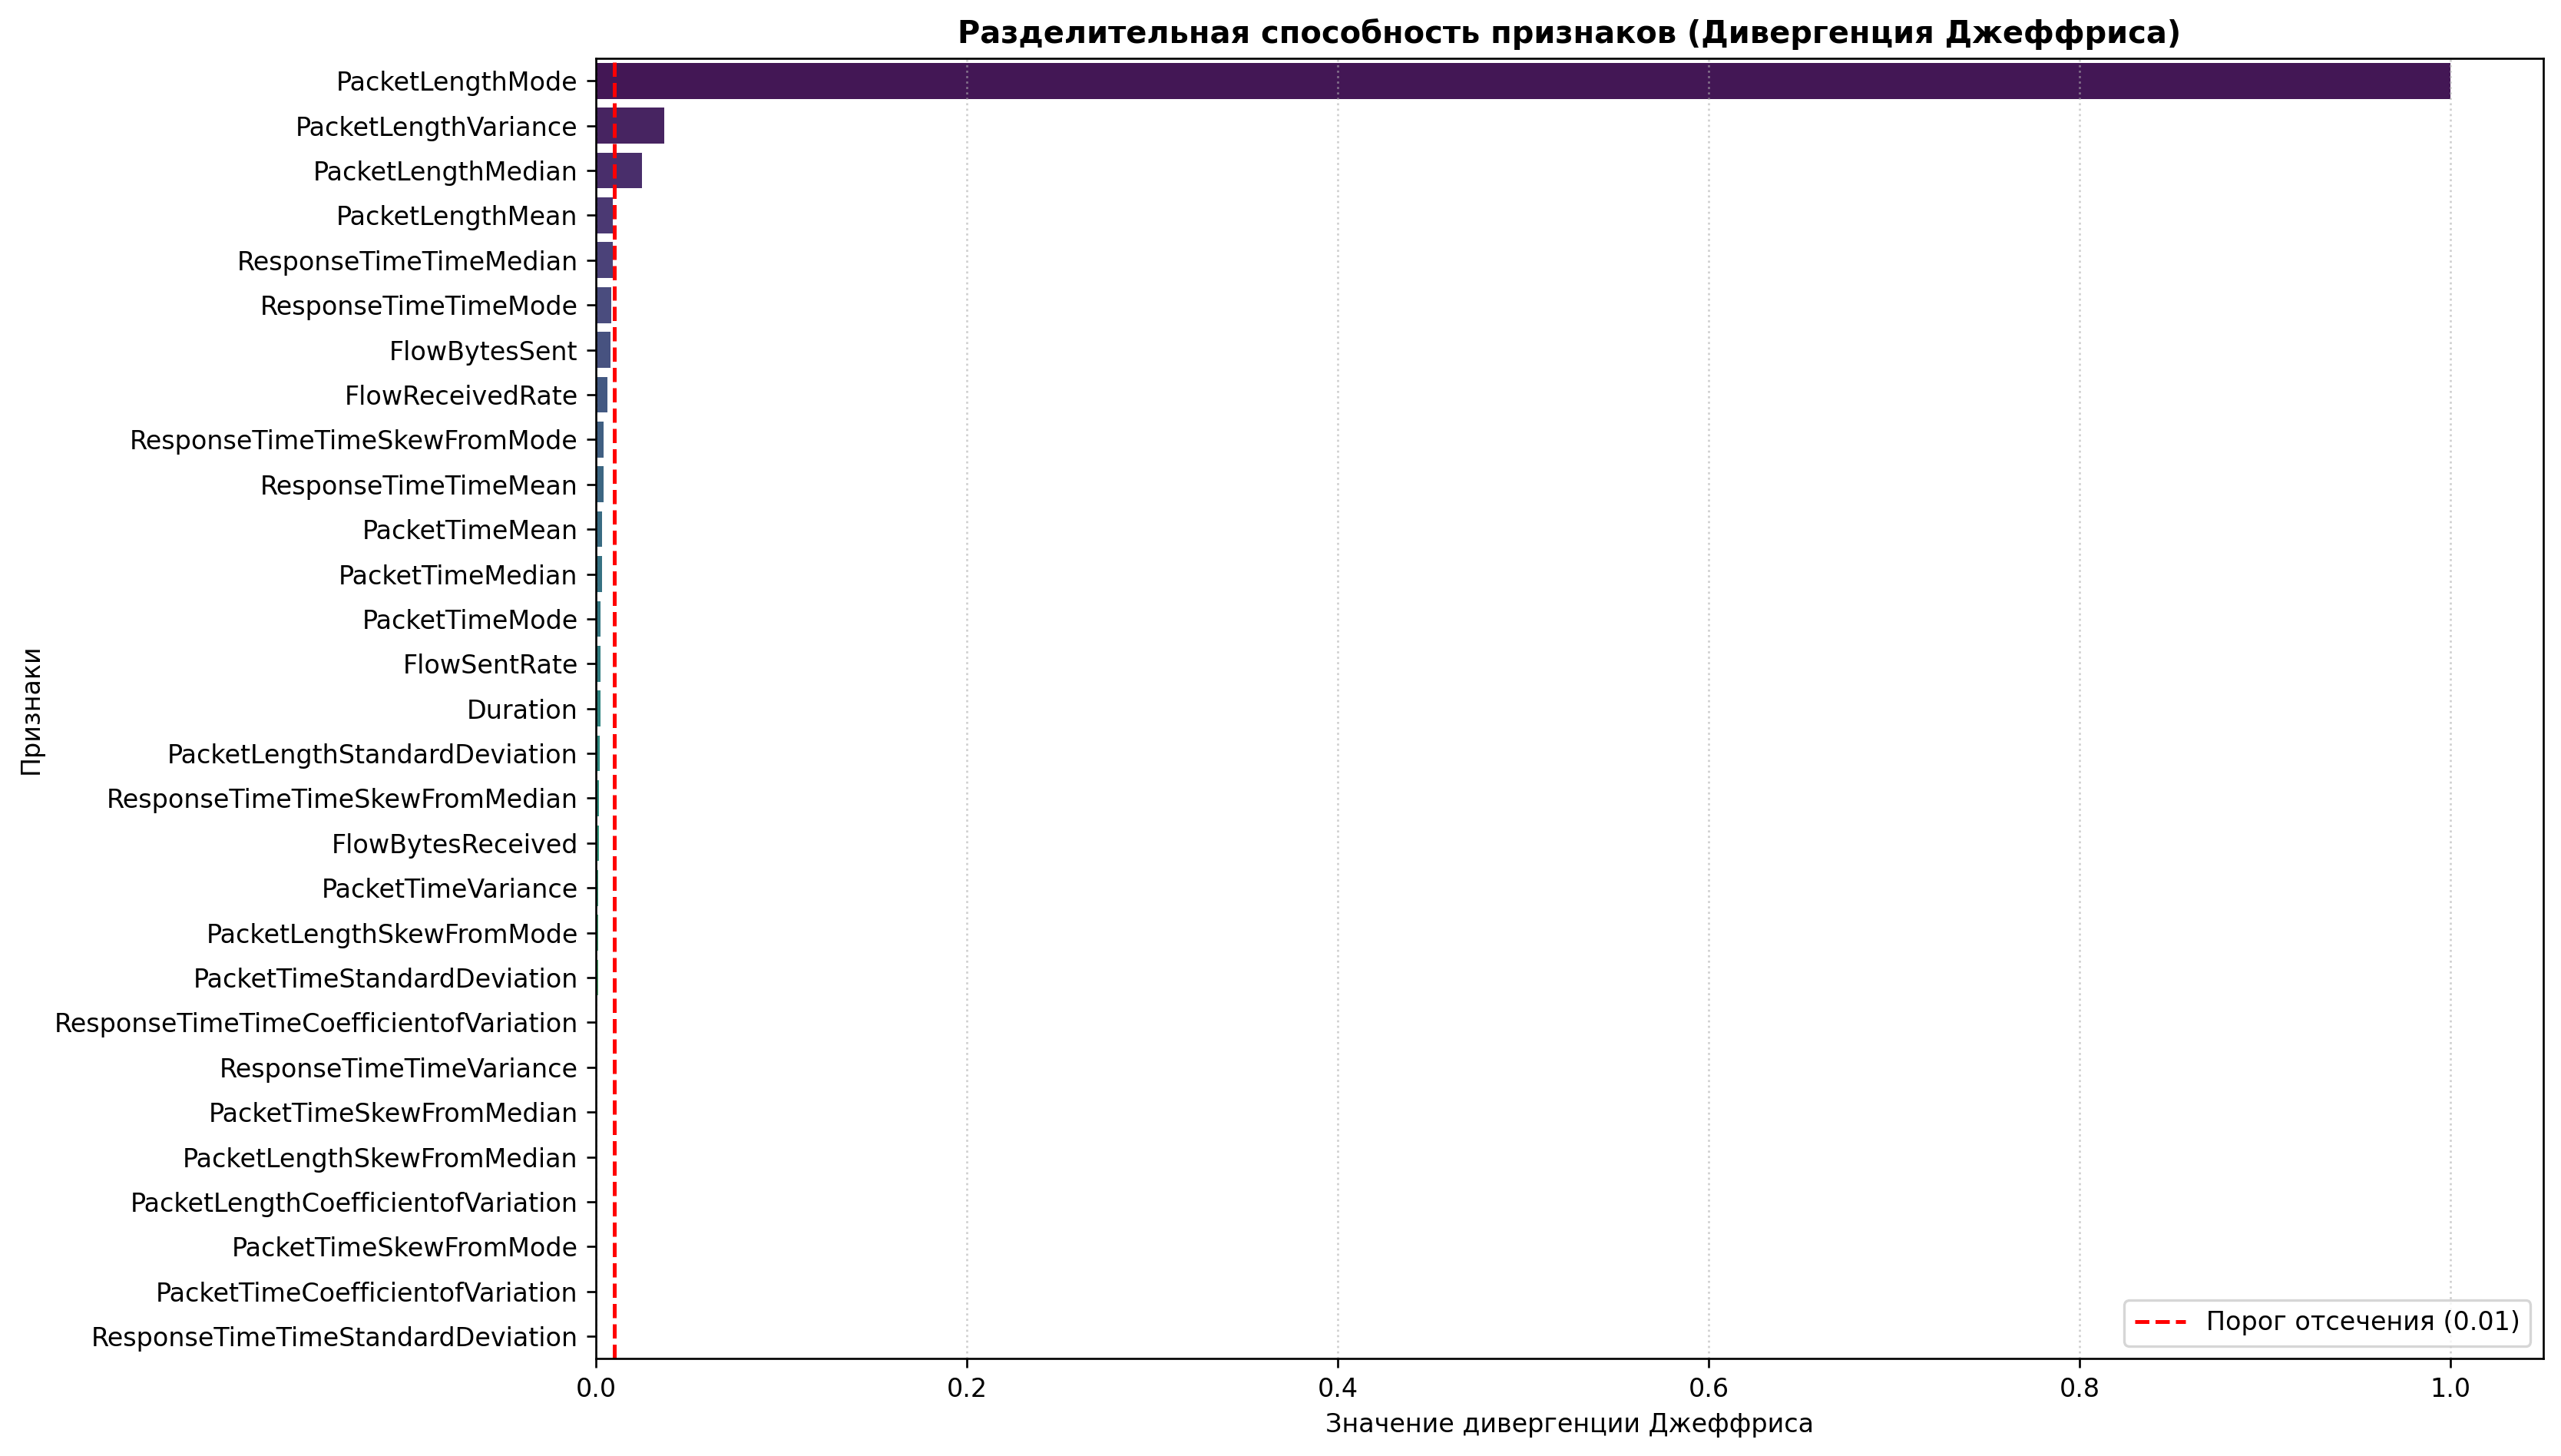

In [39]:
# График дивергенции Джеффриса для признаков (вертикальный)
plt.figure(figsize=(14, 8), dpi=240)

# ИССПРАВЛЕНО: x='Jeffreys_Divergence' и y='Feature' (соответствует именам в jd_df)
sns.barplot(data=jd_df_norm.head(29), x='Jeffreys_Divergence', y='Feature', palette='viridis')

# ИСПРАВЛЕНО: Изменено название на Джеффриса
plt.title('Разделительная способность признаков (Дивергенция Джеффриса)', fontsize=12, fontweight='bold')

# ИСПРАВЛЕНО: Изменена подпись оси X
plt.xlabel('Значение дивергенции Джеффриса', fontsize=10)
plt.ylabel('Признаки', fontsize=10)

plt.axvline(x=0.01, color='red', linestyle='--', label='Порог отсечения (0.01)') # Добавили цвет для наглядности порога
plt.legend()
plt.tight_layout()
plt.grid(axis='x', linestyle=':', alpha=0.6) # Сетка только по вертикали для лучшей читаемости
plt.savefig("output_7.png", dpi=400)
plt.show()

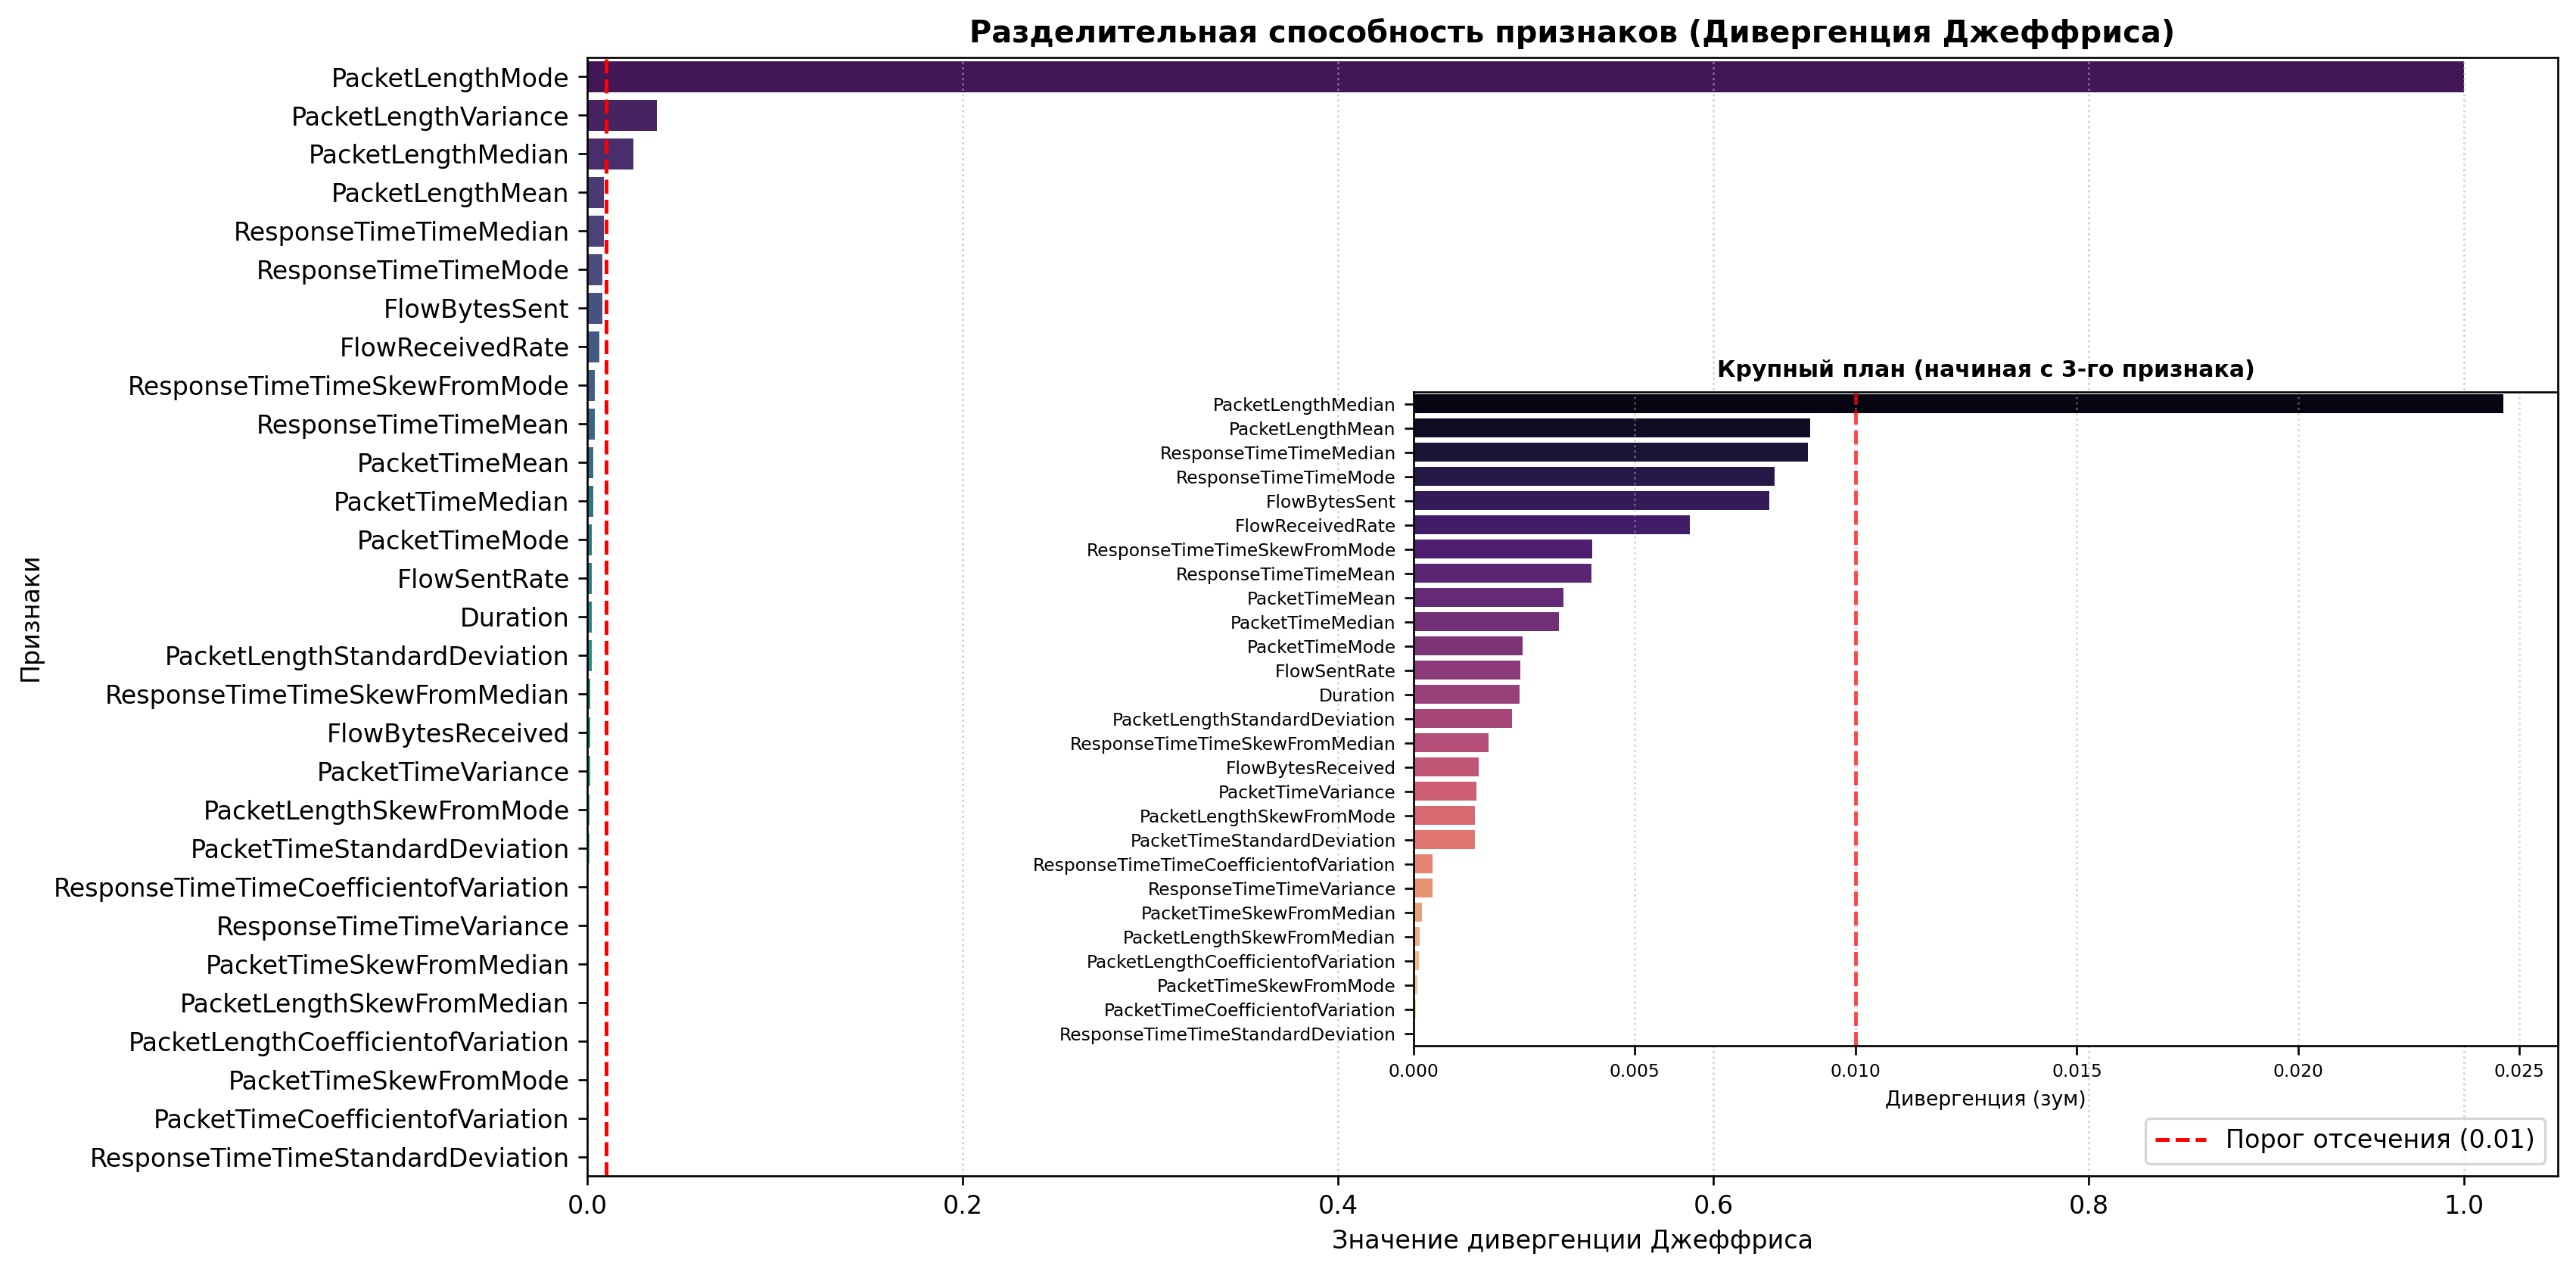

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Инициализируем фигуру и основной объект осей (ax1)
fig, ax1 = plt.subplots(figsize=(14, 8), dpi=240)

# 1. СТРОИМ ОСНОВНОЙ ГРАФИК (все 29 признаков)
sns.barplot(
    data=jd_df_norm.head(29), 
    x='Jeffreys_Divergence', 
    y='Feature', 
    palette='viridis',
    ax=ax1 # Явно указываем основные оси
)

ax1.set_title('Разделительная способность признаков (Дивергенция Джеффриса)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Значение дивергенции Джеффриса', fontsize=10)
ax1.set_ylabel('Признаки', fontsize=10)
ax1.axvline(x=0.01, color='red', linestyle='--', label='Порог отсечения (0.01)')
ax1.legend(loc='lower right') # Переносим легенду вниз, чтобы не мешала мини-графику
ax1.grid(axis='x', linestyle=':', alpha=0.6)

# 2. СОЗДАЕМ ВНУТРЕННИЙ МИНИ-ГРАФИК (Inset Plot)
# Координаты внутри фигуры: [отступ_слева, отступ_снизу, ширина, высота] в долях от 0 до 1
# Размещаем его в свободном правом верхнем углу
ax_inset = fig.add_axes([0.45, 0.20, 0.45, 0.45]) 

# Берем данные начиная со 2-го или 3-го признака (индекс 2 в .iloc означает с ТРЕТЬЕГО признака)
# Если нужно со второго, замените на .iloc[1:]
inset_data = jd_df_norm.iloc[2:29]

sns.barplot(
    data=inset_data, 
    x='Jeffreys_Divergence', 
    y='Feature', 
    palette='magma', # Другая палитра, чтобы графики визуально отличались
    ax=ax_inset # Рисуем на внутренних осях
)

# Настраиваем мини-график
ax_inset.set_title('Крупный план (начиная с 3-го признака)', fontsize=9, fontweight='bold')
ax_inset.set_xlabel('Дивергенция (зум)', fontsize=8)
ax_inset.set_ylabel('', fontsize=8) # Убираем дублирующую подпись оси Y
ax_inset.tick_params(axis='both', which='major', labelsize=7) # Уменьшаем размер шрифта меток
ax_inset.axvline(x=0.01, color='red', linestyle='--', alpha=0.7)
ax_inset.grid(axis='x', linestyle=':', alpha=0.5)
plt.savefig("output_8.png", dpi=400)
# Отображаем итоговую композицию
plt.show()

### Сравним важность признаков, полученную разными методами

In [41]:
from sklearn.preprocessing import MinMaxScaler

# 1. Проверяем/приводим имена колонок к единому стандарту
# Допустим, в importance_df колонка с именами называется 'feature', а важность — 'importance'
# (если у вас другие названия, замените их ниже)

# 2. Объединяем таблицы по названию признака (подразумеваем, что имена колонок 'feature' или 'Feature')
# Приведем названия колонок к нижнему регистру для надежности объединения
importance_df.columns = [col.lower() for col in importance_df.columns]
jd_df_norm.columns = [col.lower() for col in jd_df_norm.columns]

# Делаем merge (соединение)
compared_df = pd.merge(importance_df, jd_df_norm, on='feature', how='inner')

# 3. Нормируем обе метрики от 0 до 100% для честного сравнения
mm_scaler = MinMaxScaler()

# Нормируем Random Forest (ищем колонку importance или схожую)
rf_col = [c for c in compared_df.columns if 'importance' in c][0]
compared_df['RF_Importance_%'] = mm_scaler.fit_transform(compared_df[[rf_col]]) * 100

# Нормируем Дивергенцию Джеффриса
jd_col = [c for c in compared_df.columns if 'divergence' in c][0]
compared_df['Jeffreys_Divergence_%'] = mm_scaler.fit_transform(compared_df[[jd_col]]) * 100

# 4. Считаем разницу между метриками, чтобы увидеть аномалии
# (какие признаки один метод переоценил, а другой недооценил)
compared_df['Difference'] = compared_df['RF_Importance_%'] - compared_df['Jeffreys_Divergence_%']

# 5. Сортируем по важности Random Forest и выводим финальную таблицу
final_table = compared_df[['feature', 'RF_Importance_%', 'Jeffreys_Divergence_%', 'Difference']].sort_values(
    by='RF_Importance_%', 
    ascending=False
).reset_index(drop=True)

print("Сводная таблица сравнения признаков (в % от максимума):")
#print(final_table.head(29))

final_table.head(29)

Сводная таблица сравнения признаков (в % от максимума):


,feature,RF_Importance_%,Jeffreys_Divergence_%,Difference
0,PacketLengthMode,100.000000,100.000000,-1.421085e-14
1,Duration,32.146741,0.239178,3.190756e+01
2,PacketLengthMean,23.221937,0.896033,2.232590e+01
3,PacketLengthMedian,22.525707,2.463570,2.006214e+01
4,ResponseTimeTimeMedian,22.245668,0.891150,2.135452e+01
5,PacketTimeMean,20.397241,0.337203,2.006004e+01
6,FlowBytesSent,18.002879,0.803547,1.719933e+01
7,PacketTimeStandardDeviation,14.446369,0.137799,1.430857e+01
8,PacketLengthStandardDeviation,13.343674,0.221561,1.312211e+01
9,PacketLengthCoefficientofVariation,12.327909,0.010258,1.231765e+01


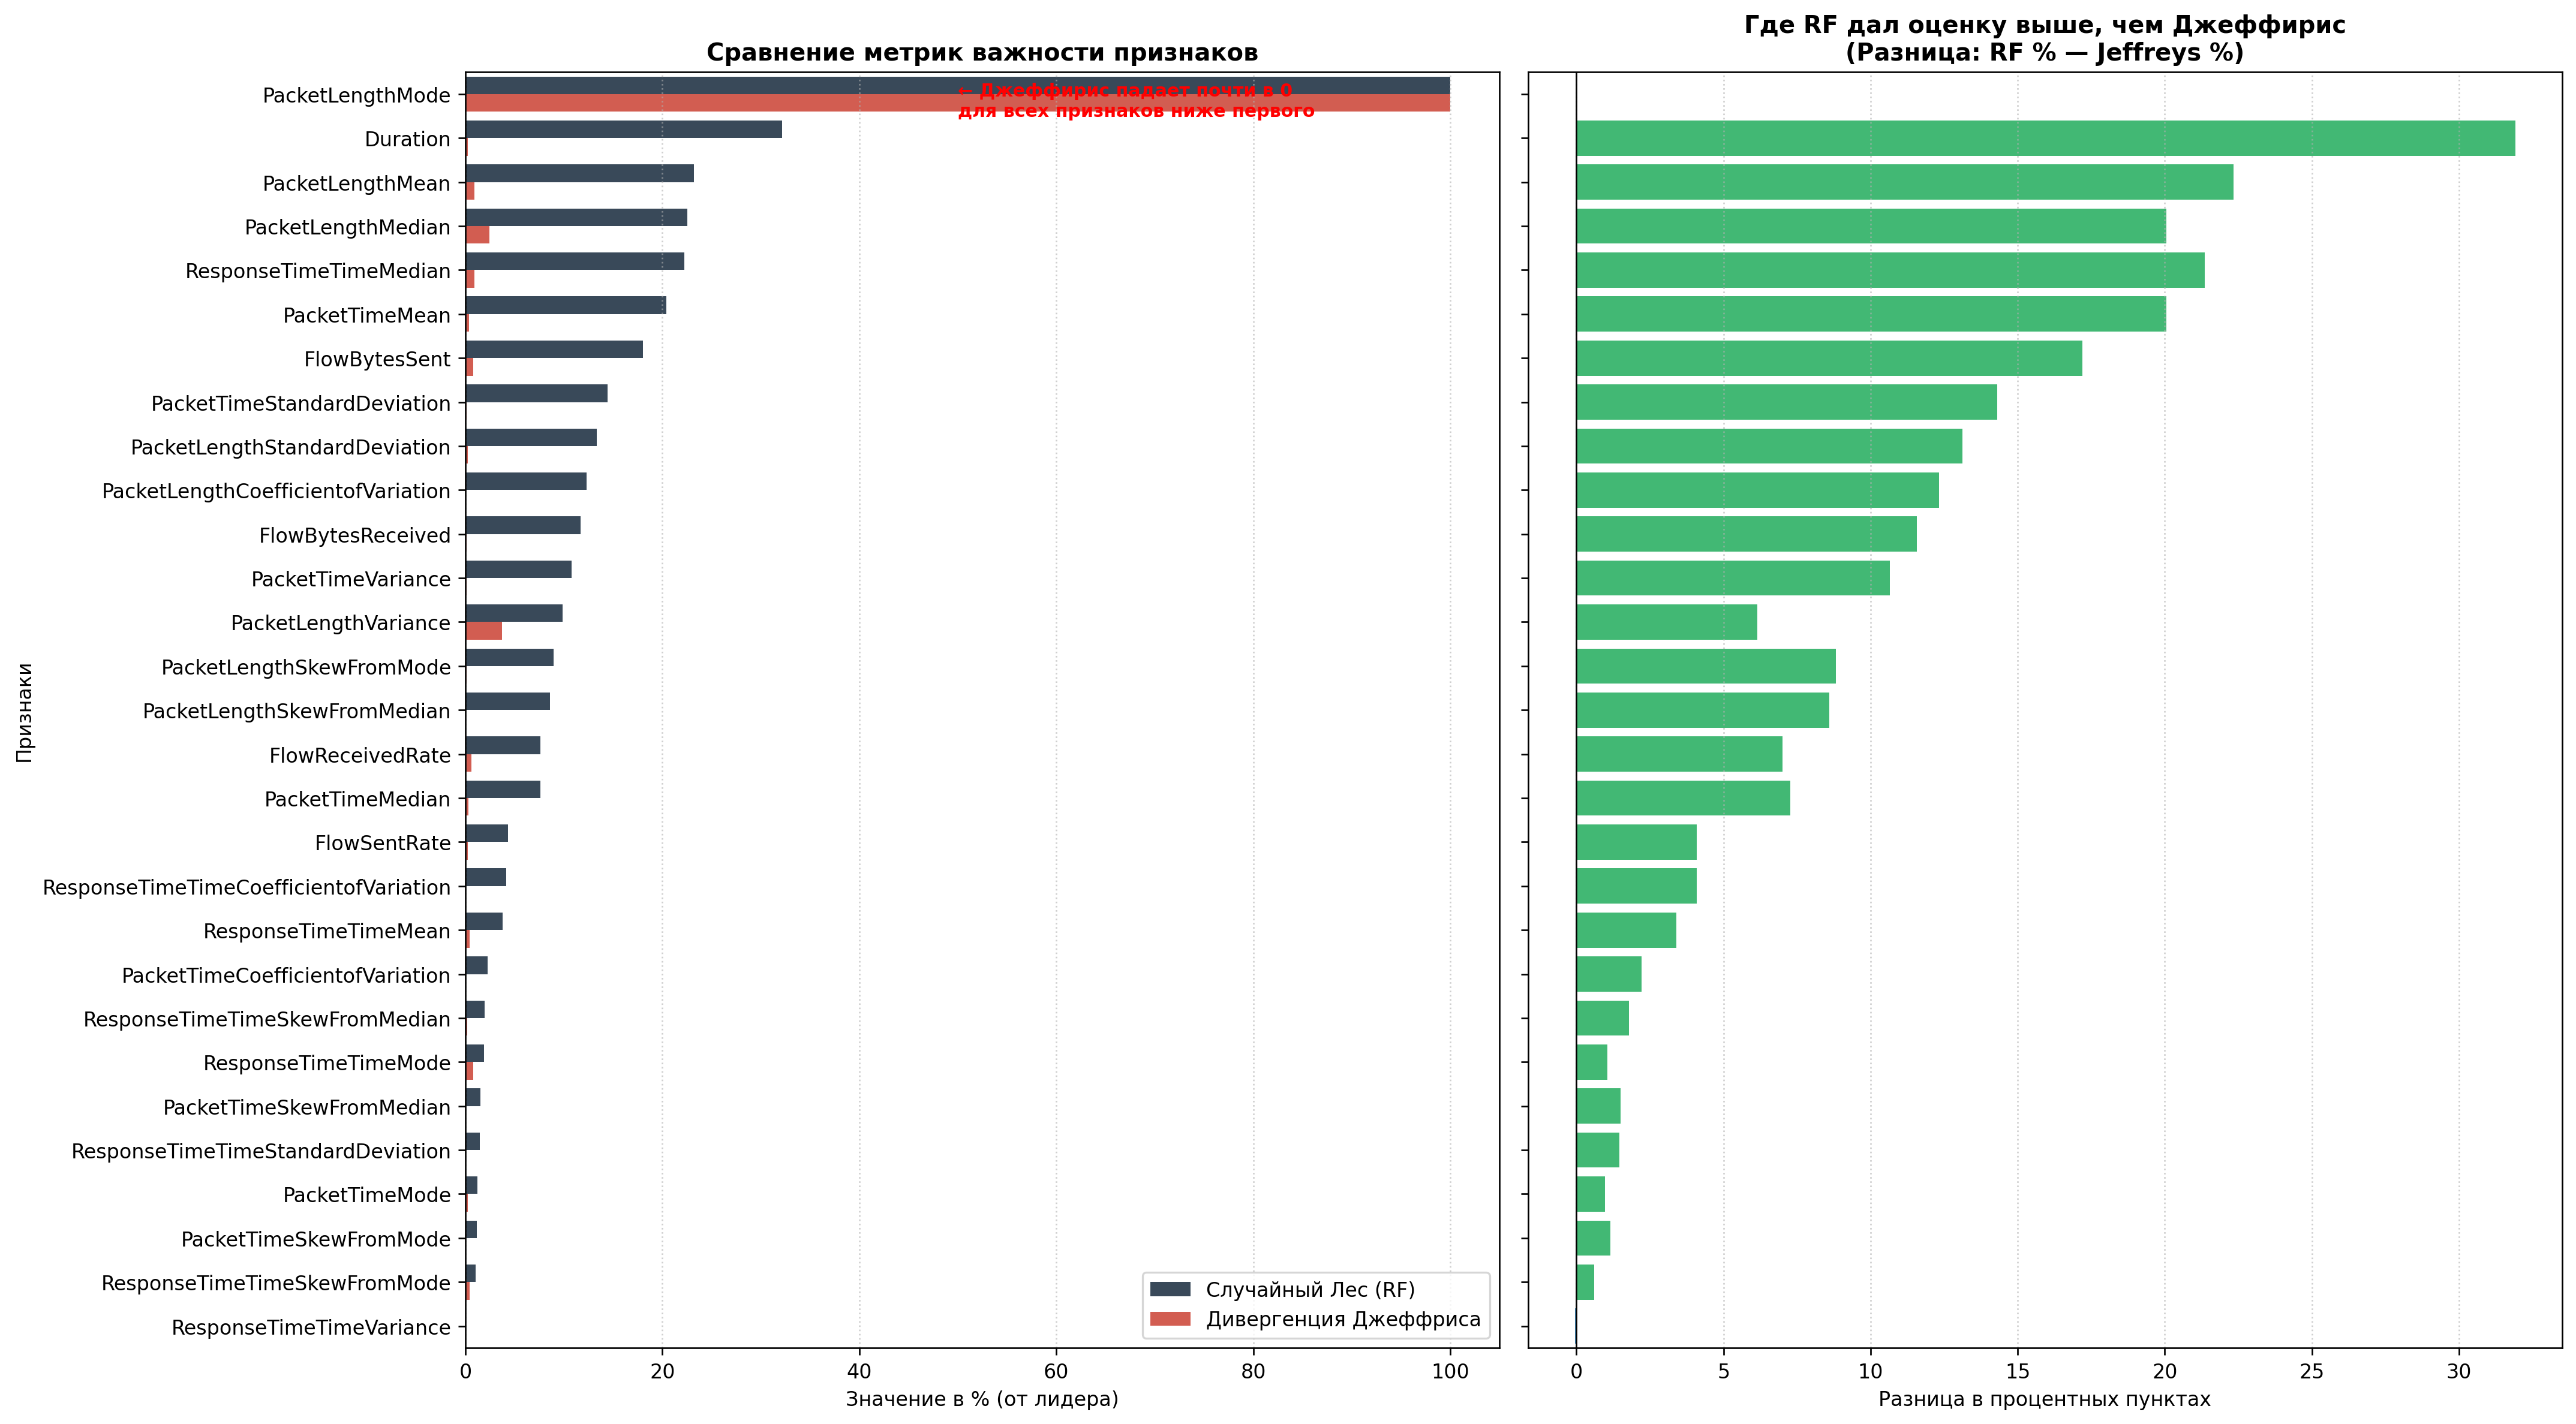

In [42]:
# 1. Подготовка данных (если числа еще не в датафрейме, создаем его)
# final_table = ... (ваш текущий DataFrame)

# Убираем экспоненциальную запись нуля для Difference (-1.42e-14 превращаем в 0.0)
final_table["Difference"] = final_table["Difference"].apply(
    lambda x: 0.0 if abs(x) < 1e-10 else x
)

# 2. Настройка холста для двух графиков рядом
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10), dpi=240, sharey=True)

# Исходные данные широкого формата нужно перевести в длинный (melt) для seaborn
df_melted = final_table.melt(
    id_vars="feature",
    value_vars=["RF_Importance_%", "Jeffreys_Divergence_%"],
    var_name="Metric",
    value_name="Percentage",
)

# Изменяем названия метрик для легенды графика
df_melted["Metric"] = df_melted["Metric"].replace(
    {
        "RF_Importance_%": "Случайный Лес (RF)",
        "Jeffreys_Divergence_%": "Дивергенция Джеффриса",
    }
)

# --- ГРАФИК 1: Сравнение RF и Джеффриса (Сдвоенные бары) ---
sns.barplot(
    data=df_melted,
    y="feature",
    x="Percentage",
    hue="Metric",
    palette=["#34495e", "#e74c3c"],
    ax=ax1,
)
ax1.set_title(
    "Сравнение метрик важности признаков", fontsize=12, fontweight="bold"
)
ax1.set_xlabel("Значение в % (от лидера)", fontsize=10)
ax1.set_ylabel("Признаки", fontsize=10)
ax1.grid(axis="x", linestyle=":", alpha=0.6)
ax1.legend(loc="lower right")

# Добавляем текстовую подсказку прямо на график о сильном масштабе первого признака
ax1.text(
    50,
    0.5,
    "← Джеффирис падает почти в 0\nдля всех признаков ниже первого",
    color="red",
    fontsize=9,
    fontweight="bold",
)

# --- ГРАФИК 2: Разница между ними (Difference) ---
# Назначаем цвета: если разница >, то зеленый (RF переоценил), если <, то синий
colors = [
    "#2ecc71" if x >= 0 else "#3498db" for x in final_table["Difference"]
]

sns.barplot(
    data=final_table, y="feature", x="Difference", palette=colors, ax=ax2
)
ax2.set_title(
    "Где RF дал оценку выше, чем Джеффирис\n(Разница: RF % — Jeffreys %)",
    fontsize=12,
    fontweight="bold",
)
ax2.set_xlabel("Разница в процентных пунктах", fontsize=10)
ax2.set_ylabel("")  # Убираем дублирование названий признаков
ax2.grid(axis="x", linestyle=":", alpha=0.6)

# Рисуем центральную линию нуля
ax2.axvline(0, color="black", linestyle="-", linewidth=0.8)

# Корректируем отступы, чтобы всё влезло
plt.tight_layout()
plt.savefig("output_9.png", dpi=400)
plt.show()

### Проверка классификационных свойств выборки по Джеффирису.


In [43]:
# 1. Задаем порог отсечения (в процентах от максимума)
# Оставим признаки, у которых информативность выше 0.1%
threshold_percent = 0.1

# 2. Находим имена признаков, которые прошли этот порог
# (Используем ваш датафрейм, где посчитана колонка Jeffreys_Divergence_%)
selected_features = final_table[final_table['Jeffreys_Divergence_%'] >= threshold_percent]['feature'].tolist()

print(f"Выбрано признаков по Джеффрису: {len(selected_features)} из {len(final_table)}")
print("\nВыбранные признаки:\n" + "\n".join(f"  - {f}" for f in selected_features))


deleted_features = set(final_table['feature']) - set(selected_features)
print(f"\nУдалено признаков: {len(deleted_features)}")
print("\nУдаленные (слабые) признаки:\n" + "\n".join(f"  - {f}" for f in deleted_features))

# 3. Формируем новые, отфильтрованные выборки Train и Test
X_train_jf = X_train[selected_features]
X_test_jf = X_test[selected_features]

# 4. Проверяем новые размеры таблиц
print(f"\nНовый размер обучающей выборки (X_train_jf): {X_train_jf.shape}")
print(f"Новый размер тестовой выборки (X_test_jf): {X_test_jf.shape}")


Выбрано признаков по Джеффрису: 21 из 29

Выбранные признаки:
  - PacketLengthMode
  - Duration
  - PacketLengthMean
  - PacketLengthMedian
  - ResponseTimeTimeMedian
  - PacketTimeMean
  - FlowBytesSent
  - PacketTimeStandardDeviation
  - PacketLengthStandardDeviation
  - FlowBytesReceived
  - PacketTimeVariance
  - PacketLengthVariance
  - PacketLengthSkewFromMode
  - FlowReceivedRate
  - PacketTimeMedian
  - FlowSentRate
  - ResponseTimeTimeMean
  - ResponseTimeTimeSkewFromMedian
  - ResponseTimeTimeMode
  - PacketTimeMode
  - ResponseTimeTimeSkewFromMode

Удалено признаков: 8

Удаленные (слабые) признаки:
  - PacketLengthSkewFromMedian
  - PacketTimeSkewFromMode
  - ResponseTimeTimeStandardDeviation
  - PacketLengthCoefficientofVariation
  - ResponseTimeTimeVariance
  - ResponseTimeTimeCoefficientofVariation
  - PacketTimeCoefficientofVariation
  - PacketTimeSkewFromMedian

Новый размер обучающей выборки (X_train_jf): (815293, 21)
Новый размер тестовой выборки (X_test_jf): (203824,

### Анализ модели, 1. Оценка точности на всех признаках, 2. Проверка на новом наборе. 3. Сравнение результатов.

In [44]:
from sklearn.metrics import classification_report, accuracy_score, f1_score
# Настройки модели (ограничим n_jobs=-1 для задействования всех ядер процессора)
# Если у вас очень мощный ПК, n_estimators можно увеличить до 100
rf_params = {
    'n_estimators': 50, 
    'max_depth': 12,    # Ограничим глубину для ускорения эксперимента
    'random_state': 42,
    'n_jobs': -1
}

# =====================================================================
# 1. ОБУЧЕНИЕ НА ВСЕХ ПРИЗНАКАХ (29 шт)
# =====================================================================
print("--- Шаг 1: Обучение модели на ВСЕХ признаках ---")
start_time = time.time()

rf_full = RandomForestClassifier(**rf_params)
rf_full.fit(X_train, y_train)

full_train_time = time.time() - start_time
y_pred_full = rf_full.predict(X_test)

# Считаем метрики
acc_full = accuracy_score(y_test, y_pred_full)
f1_full = f1_score(y_test, y_pred_full, average='macro')

print(f"Время обучения: {full_train_time:.2f} сек.")
print(f"Accuracy (Все признаки): {acc_full:.4f}")
print(f"F1-Score Macro (Все признаки): {f1_full:.4f}\n")


# =====================================================================
# 2. ОБУЧЕНИЕ НА ПРИЗНАКАХ ДЖЕФФРИСА (отфильтрованных)
# =====================================================================
print("--- Шаг 2: Обучение модели на признаках по Джеффрису ---")
start_time = time.time()

rf_jf = RandomForestClassifier(**rf_params)
rf_jf.fit(X_train_jf, y_train)

jf_train_time = time.time() - start_time
y_pred_jf = rf_jf.predict(X_test_jf)

# Считаем метрики
acc_jf = accuracy_score(y_test, y_pred_jf)
f1_jf = f1_score(y_test, y_pred_jf, average='macro')

print(f"Время обучения: {jf_train_time:.2f} сек.")
print(f"Accuracy (Джеффрис): {acc_jf:.4f}")
print(f"F1-Score Macro (Джеффрис): {f1_jf:.4f}\n")


# =====================================================================
# 3. СРАВНИТЕЛЬНЫЙ АНАЛИЗ
# =====================================================================
print("=== ИТОГОВОЕ СРАВНЕНИЕ ===")
time_saved = full_train_time - jf_train_time
f1_diff = f1_full - f1_jf

print(f"Экономия времени: {time_saved:.2f} сек. ({ (time_saved/full_train_time)*100:.1f}% быстрее)")
print(f"Разница в качестве (F1-score): {f1_diff:.4f} (близко к нулю — значит, удаленные признаки были лишними)")

print("\nПодробный отчет по классам для модели на признаках Джеффриса:")
print(classification_report(y_test, y_pred_jf, target_names=['NonDoH (0)', 'DoH (1)']))

--- Шаг 1: Обучение модели на ВСЕХ признаках ---
Время обучения: 36.87 сек.
Accuracy (Все признаки): 0.9958
F1-Score Macro (Все признаки): 0.9946

--- Шаг 2: Обучение модели на признаках по Джеффрису ---
Время обучения: 28.68 сек.
Accuracy (Джеффрис): 0.9958
F1-Score Macro (Джеффрис): 0.9946

=== ИТОГОВОЕ СРАВНЕНИЕ ===
Экономия времени: 8.19 сек. (22.2% быстрее)
Разница в качестве (F1-score): 0.0000 (близко к нулю — значит, удаленные признаки были лишними)

Подробный отчет по классам для модели на признаках Джеффриса:
              precision    recall  f1-score   support

  NonDoH (0)       1.00      0.99      0.99     53732
     DoH (1)       0.99      1.00      1.00    150092

    accuracy                           1.00    203824
   macro avg       1.00      0.99      0.99    203824
weighted avg       1.00      1.00      1.00    203824



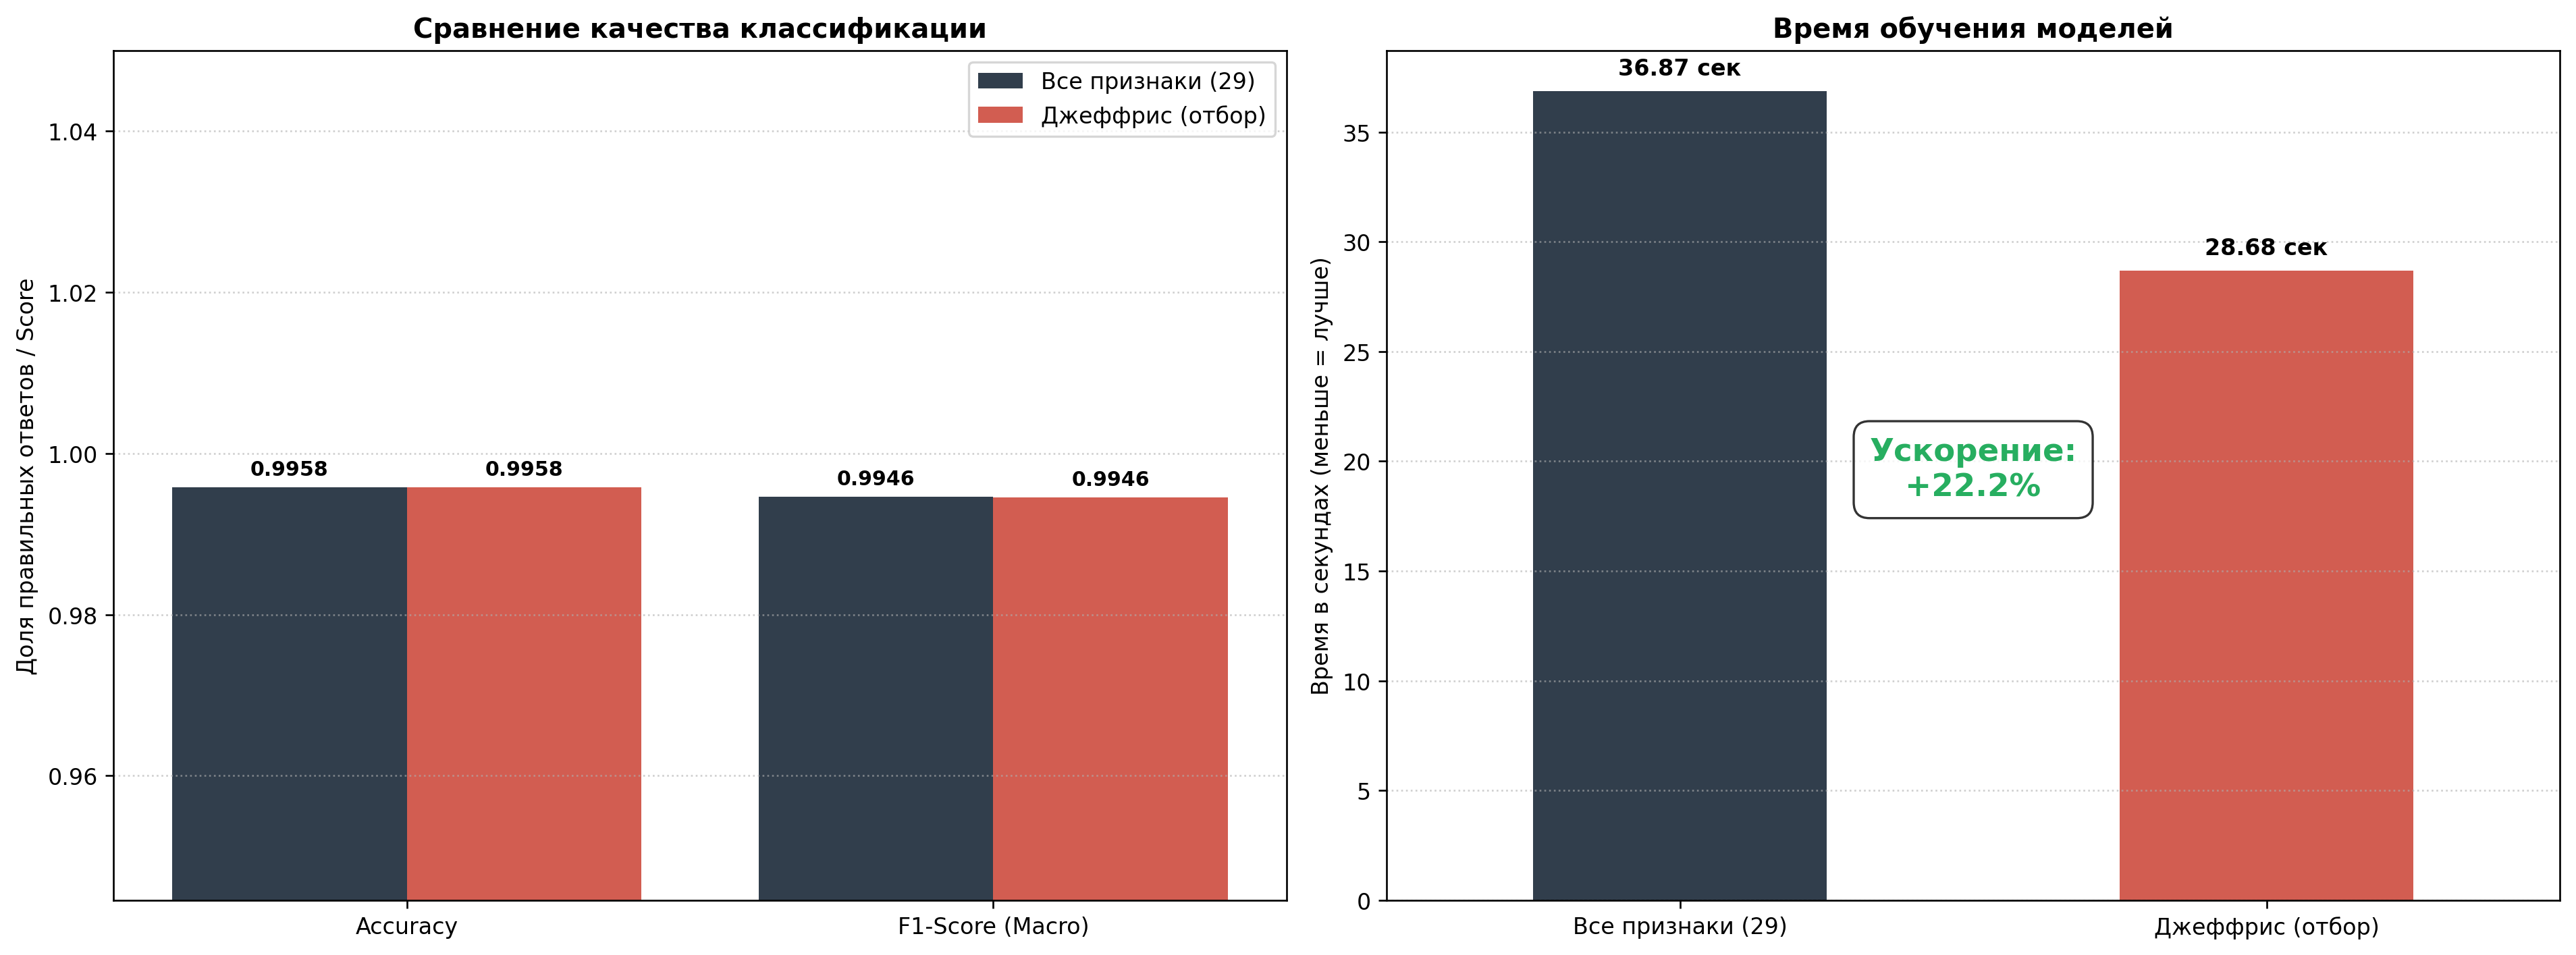

In [45]:
# 1. Собираем данные из результатов эксперимента
# (Если вы перезапустили ячейку, переменные acc_full, acc_jf, f1_full, f1_jf, full_train_time, jf_train_time уже созданы)

metrics_data = {
    "Модель": [
        "Все признаки (29)",
        "Все признаки (29)",
        "Джеффрис (отбор)",
        "Джеффрис (отбор)",
    ],
    "Метрика": ["Accuracy", "F1-Score (Macro)", "Accuracy", "F1-Score (Macro)"],
    "Значение": [acc_full, f1_full, acc_jf, f1_jf],
}

# 2. Настраиваем холст на два графика рядом
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=240)

# --- ГРАФИК 1: Сравнение качества моделей (Accuracy и F1) ---
sns.barplot(
    data=metrics_data,
    x="Метрика",
    y="Значение",
    hue="Модель",
    palette=["#2c3e50", "#e74c3c"],
    ax=ax1,
)

ax1.set_title("Сравнение качества классификации", fontsize=12, fontweight="bold")
ax1.set_ylabel("Доля правильных ответов / Score", fontsize=10)
ax1.set_xlabel("")
ax1.grid(axis="y", linestyle=":", alpha=0.6)

# Автоматически добавляем точные значения над столбцами
for p in ax1.patches:
    if p.get_height() > 0:  # Проверка на пустые элементы легенды
        ax1.annotate(
            f"{p.get_height():.4f}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            xytext=(0, 8),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
        )

# Немного приподнимем лимит оси Y, чтобы цифры сверху не обрезались
ax1.set_ylim(min(f1_full, f1_jf) - 0.05, 1.05)


# --- ГРАФИК 2: Сравнение времени обучения (Тайминг) ---
times = [full_train_time, jf_train_time]
models = ["Все признаки (29)", "Джеффрис (отбор)"]

sns.barplot(x=models, y=times, palette=["#2c3e50", "#e74c3c"], ax=ax2, width=0.5)

ax2.set_title("Время обучения моделей", fontsize=12, fontweight="bold")
ax2.set_ylabel("Время в секундах (меньше = лучше)", fontsize=10)
ax2.grid(axis="y", linestyle=":", alpha=0.6)

# Добавляем подписи секунд над столбцами времени
for i, v in enumerate(times):
    ax2.text(i, v + (max(times) * 0.02), f"{v:.2f} сек", ha="center", fontweight="bold")

# Считаем и выводим процент ускорения прямо на графике времени
speedup = ((full_train_time - jf_train_time) / full_train_time) * 100
ax2.text(
    0.5,
    max(times) * 0.5,
    f"Ускорение:\n+{speedup:.1f}%",
    color="#27ae60",
    fontsize=14,
    fontweight="bold",
    ha="center",
    bbox=dict(facecolor="white", alpha=0.8, boxstyle="round,pad=0.5"),
)
plt.savefig("output_10.png", dpi=400)
plt.tight_layout()
plt.show()

In [46]:
### Проверим расширенный расчет, непараметрический.

Расчет KL-дивергенции для каждого признака...
Это может занять несколько минут...
Обработано 0/29 признаков...
Обработано 5/29 признаков...
Обработано 10/29 признаков...
Обработано 15/29 признаков...
Обработано 20/29 признаков...
Обработано 25/29 признаков...

=== РАНЖИРОВАНИЕ ПРИЗНАКОВ ПО KL-ДИВЕРГЕНЦИИ ===
                           feature  kl_divergence  js_divergence  ks_statistic  ks_pvalue
                  PacketLengthMode       7.172411       0.348561      0.711478        0.0
                  PacketLengthMean       4.821473       0.558832      0.411015        0.0
                 FlowBytesReceived       4.816966       0.617975      0.304625        0.0
PacketLengthCoefficientofVariation       3.559075       0.489105      0.270122        0.0
                PacketLengthMedian       3.478933       0.510841      0.414818        0.0
          PacketLengthSkewFromMode       3.025672       0.478821      0.245709        0.0
        PacketLengthSkewFromMedian       3.025131       0.49

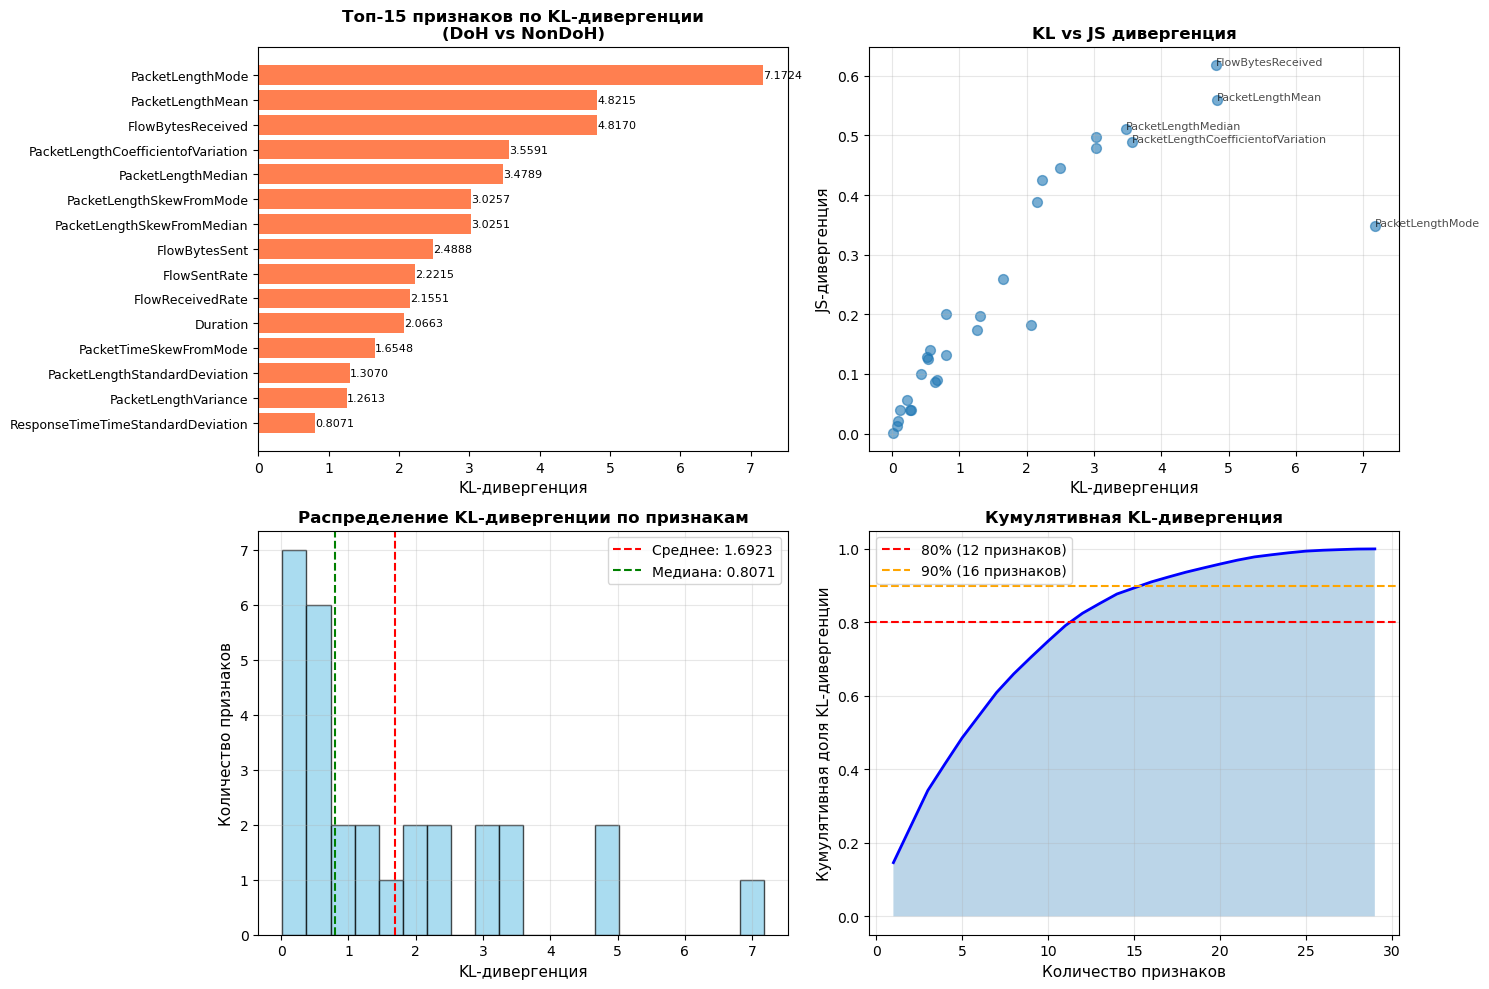


=== СТАТИСТИКА ===
Признаков с KL > 0: 29
Максимальная KL: 7.1724 - признак 'PacketLengthMode'
Минимальная KL: 0.0192 - признак 'PacketTimeCoefficientofVariation'


In [47]:
import pandas as pd
import numpy as np
from scipy.stats import entropy, ks_2samp
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_parquet('L1-DoH-NonDoH.parquet')
X = df.drop('Label', axis=1)
y = df['Label']

# Разделение по классам
X_doh = X[y == 'DoH']
X_nondoh = X[y == 'NonDoH']

def calculate_kl_divergence(p_values, q_values, bins=50):
    """
    Расчет KL-дивергенции между двумя распределениями
    
    KL(P||Q) = Σ P(x) * log(P(x)/Q(x))
    """
    # Определяем общие границы бинов на основе объединенных данных
    all_values = np.concatenate([p_values, q_values])
    
    # Используем процентили для равномерного распределения бинов
    bins_edges = np.percentile(all_values, np.linspace(0, 100, bins+1))
    bins_edges = np.unique(bins_edges)  # Убираем дубликаты
    
    # Если слишком мало уникальных границ, используем автоматические бины
    if len(bins_edges) < 2:
        bins_edges = np.linspace(min(all_values), max(all_values), bins+1)
    
    # Гистограммы для каждого распределения
    p_hist, _ = np.histogram(p_values, bins=bins_edges, density=True)
    q_hist, _ = np.histogram(q_values, bins=bins_edges, density=True)
    
    # Добавляем маленькое значение для избежания log(0)
    epsilon = 1e-10
    p_hist = p_hist + epsilon
    q_hist = q_hist + epsilon
    
    # Нормализация
    p_hist = p_hist / p_hist.sum()
    q_hist = q_hist / q_hist.sum()
    
    # KL-дивергенция
    kl_div = np.sum(p_hist * np.log(p_hist / q_hist))
    
    return kl_div

def calculate_js_divergence(p_values, q_values, bins=50):
    """
    Jensen-Shannon дивергенция (симметричная версия KL)
    """
    # Определяем общие границы бинов
    all_values = np.concatenate([p_values, q_values])
    bins_edges = np.percentile(all_values, np.linspace(0, 100, bins+1))
    bins_edges = np.unique(bins_edges)
    
    if len(bins_edges) < 2:
        bins_edges = np.linspace(min(all_values), max(all_values), bins+1)
    
    # Гистограммы
    p_hist, _ = np.histogram(p_values, bins=bins_edges, density=True)
    q_hist, _ = np.histogram(q_values, bins=bins_edges, density=True)
    
    # Добавляем epsilon
    epsilon = 1e-10
    p_hist = p_hist + epsilon
    q_hist = q_hist + epsilon
    
    # Нормализация
    p_hist = p_hist / p_hist.sum()
    q_hist = q_hist / q_hist.sum()
    
    # Среднее распределение
    m_hist = 0.5 * (p_hist + q_hist)
    
    # JS-дивергенция
    js_div = 0.5 * np.sum(p_hist * np.log(p_hist / m_hist)) + \
             0.5 * np.sum(q_hist * np.log(q_hist / m_hist))
    
    return js_div

# Расчет дивергенций для каждого признака
kl_results = []
js_results = []
ks_pvalues = []
ks_statistics = []

print("Расчет KL-дивергенции для каждого признака...")
print("Это может занять несколько минут...")

for i, col in enumerate(X.columns):
    if i % 5 == 0:
        print(f"Обработано {i}/{len(X.columns)} признаков...")
    
    # Получаем значения для двух классов
    p_values = X_doh[col].dropna().values
    q_values = X_nondoh[col].dropna().values
    
    try:
        # KL-дивергенция
        kl_val = calculate_kl_divergence(p_values, q_values)
        kl_results.append(kl_val)
        
        # JS-дивергенция
        js_val = calculate_js_divergence(p_values, q_values)
        js_results.append(js_val)
        
        # Kolmogorov-Smirnov тест
        ks_stat, ks_p = ks_2samp(p_values, q_values)
        ks_statistics.append(ks_stat)
        ks_pvalues.append(ks_p)
        
    except Exception as e:
        print(f"Ошибка при обработке признака {col}: {e}")
        kl_results.append(0)
        js_results.append(0)
        ks_statistics.append(0)
        ks_pvalues.append(1)

# Создание DataFrame с результатами
kl_df = pd.DataFrame({
    'feature': X.columns,
    'kl_divergence': kl_results,
    'js_divergence': js_results,
    'ks_statistic': ks_statistics,
    'ks_pvalue': ks_pvalues
}).sort_values('kl_divergence', ascending=False)

print("\n=== РАНЖИРОВАНИЕ ПРИЗНАКОВ ПО KL-ДИВЕРГЕНЦИИ ===")
print(kl_df.head(10).to_string(index=False))

# Визуализация результатов
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Топ-15 по KL-дивергенции
ax1 = axes[0, 0]
top15_kl = kl_df.head(15)
ax1.barh(range(len(top15_kl)), top15_kl['kl_divergence'].values, color='coral')
ax1.set_yticks(range(len(top15_kl)))
ax1.set_yticklabels(top15_kl['feature'].values, fontsize=9)
ax1.set_xlabel('KL-дивергенция', fontsize=11)
ax1.set_title('Топ-15 признаков по KL-дивергенции\n(DoH vs NonDoH)', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# Добавляем значения на бары
for i, (bar, val) in enumerate(zip(ax1.patches, top15_kl['kl_divergence'].values)):
    ax1.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{val:.4f}', va='center', fontsize=8)

# 2. Сравнение KL и JS дивергенции
ax2 = axes[0, 1]
ax2.scatter(kl_df['kl_divergence'], kl_df['js_divergence'], alpha=0.6, s=50)
ax2.set_xlabel('KL-дивергенция', fontsize=11)
ax2.set_ylabel('JS-дивергенция', fontsize=11)
ax2.set_title('KL vs JS дивергенция', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Добавляем подписи для топ-5
for idx, row in kl_df.head(5).iterrows():
    ax2.annotate(row['feature'], (row['kl_divergence'], row['js_divergence']),
                fontsize=8, alpha=0.7)

# 3. Распределение KL-дивергенции
ax3 = axes[1, 0]
ax3.hist(kl_df['kl_divergence'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax3.axvline(kl_df['kl_divergence'].mean(), color='red', linestyle='--', 
            label=f"Среднее: {kl_df['kl_divergence'].mean():.4f}")
ax3.axvline(kl_df['kl_divergence'].median(), color='green', linestyle='--', 
            label=f"Медиана: {kl_df['kl_divergence'].median():.4f}")
ax3.set_xlabel('KL-дивергенция', fontsize=11)
ax3.set_ylabel('Количество признаков', fontsize=11)
ax3.set_title('Распределение KL-дивергенции по признакам', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Кумулятивная важность
ax4 = axes[1, 1]
sorted_kl = kl_df['kl_divergence'].sort_values(ascending=False)
cumulative_kl = sorted_kl.cumsum() / sorted_kl.sum()
ax4.plot(range(1, len(cumulative_kl)+1), cumulative_kl.values, 'b-', linewidth=2)
ax4.fill_between(range(1, len(cumulative_kl)+1), 0, cumulative_kl.values, alpha=0.3)

# Находим количество признаков для 80% и 90% дивергенции
n_80 = np.where(cumulative_kl >= 0.8)[0][0] + 1
n_90 = np.where(cumulative_kl >= 0.9)[0][0] + 1

ax4.axhline(y=0.8, color='r', linestyle='--', label=f'80% ({n_80} признаков)')
ax4.axhline(y=0.9, color='orange', linestyle='--', label=f'90% ({n_90} признаков)')
ax4.set_xlabel('Количество признаков', fontsize=11)
ax4.set_ylabel('Кумулятивная доля KL-дивергенции', fontsize=11)
ax4.set_title('Кумулятивная KL-дивергенция', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("output_11.png", dpi=400)
plt.show()

print(f"\n=== СТАТИСТИКА ===")
print(f"Признаков с KL > 0: {(kl_df['kl_divergence'] > 0).sum()}")
print(f"Максимальная KL: {kl_df['kl_divergence'].max():.4f} - признак '{kl_df.iloc[0]['feature']}'")
print(f"Минимальная KL: {kl_df['kl_divergence'].min():.4f} - признак '{kl_df.iloc[-1]['feature']}'")

                                   feature  kl_divergence  js_divergence  \
9                         PacketLengthMode       7.172411       0.348561   
7                         PacketLengthMean       4.821473       0.558832   
3                        FlowBytesReceived       4.816966       0.617975   
12      PacketLengthCoefficientofVariation       3.559075       0.489105   
8                       PacketLengthMedian       3.478933       0.510841   
11                PacketLengthSkewFromMode       3.025672       0.478821   
10              PacketLengthSkewFromMedian       3.025131       0.496724   
1                            FlowBytesSent       2.488764       0.445232   
2                             FlowSentRate       2.221503       0.425631   
4                         FlowReceivedRate       2.155084       0.388348   
0                                 Duration       2.066267       0.182347   
19                  PacketTimeSkewFromMode       1.654792       0.260039   
6           

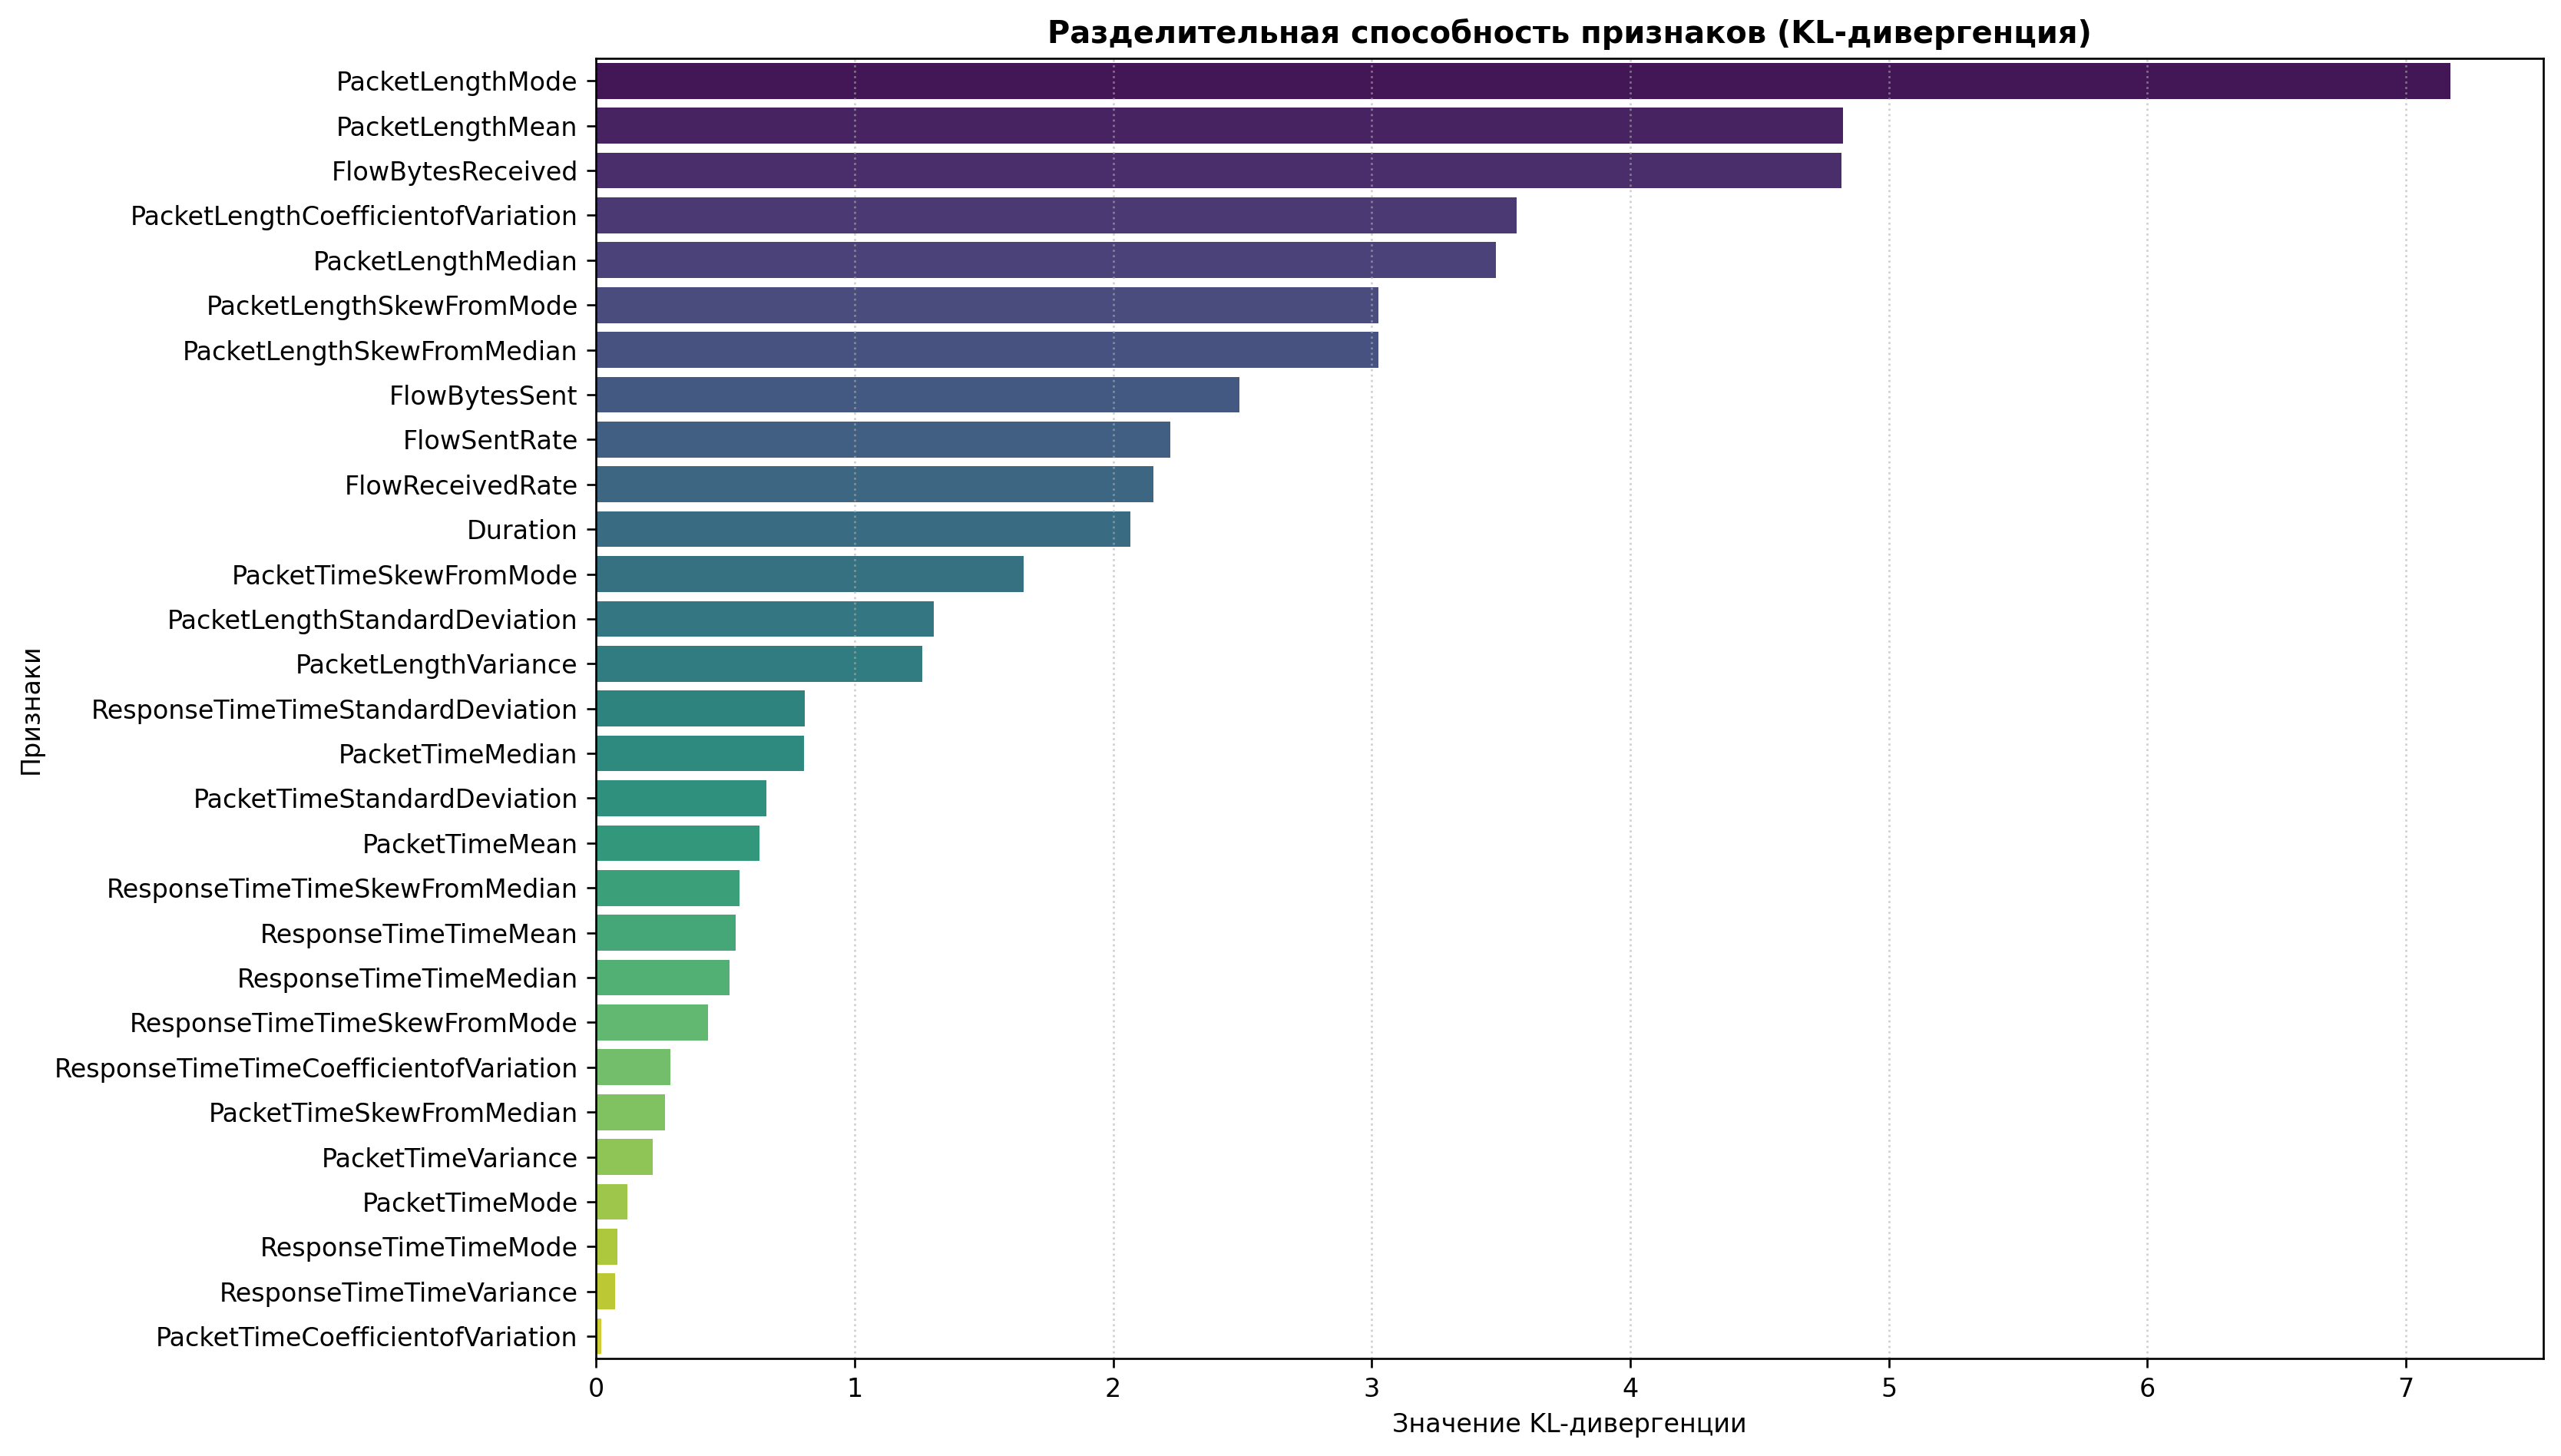

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

print(kl_df.head(29))

# График KL-дивергенции для признаков (вертикальный)
plt.figure(figsize=(14, 8), dpi=240)

sns.barplot(data=kl_df.head(29), x='kl_divergence', y='feature', palette='viridis')

plt.title('Разделительная способность признаков (KL-дивергенция)', fontsize=12, fontweight='bold')
plt.xlabel('Значение KL-дивергенции', fontsize=10)
plt.ylabel('Признаки', fontsize=10)
plt.tight_layout()
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.savefig("output_12.png", dpi=400)
plt.show()

In [49]:
from sklearn.preprocessing import MinMaxScaler

# ============================================
# 1. ПОДГОТОВКА ТАБЛИЦ
# ============================================

# Приводим названия колонок к нижнему регистру
importance_df.columns = [col.lower() for col in importance_df.columns]
jd_df_norm.columns = [col.lower() for col in jd_df_norm.columns]
kl_df.columns = [col.lower() for col in kl_df.columns]  # <-- ДОБАВЛЕНО: результаты KL/JS

# ============================================
# 2. ОБЪЕДИНЕНИЕ ТРЁХ ТАБЛИЦ
# ============================================

# Сначала объединяем Random Forest и Джеффриса
compared_df = pd.merge(importance_df, jd_df_norm, on='feature', how='inner')

# Затем добавляем KL/JS результаты
compared_df = pd.merge(compared_df, kl_df, on='feature', how='inner')

# ============================================
# 3. НОРМИРОВКА МЕТРИК ОТ 0 ДО 100%
# ============================================

mm_scaler = MinMaxScaler()

# Нормируем Random Forest
rf_col = [c for c in compared_df.columns if 'importance' in c][0]
compared_df['RF_Importance_%'] = mm_scaler.fit_transform(compared_df[[rf_col]]) * 100

# Нормируем Дивергенцию Джеффриса
jd_col = [c for c in compared_df.columns if 'jeffreys' in c.lower() or ('divergence' in c and 'kl' not in c and 'js' not in c)][0]
compared_df['Jeffreys_Divergence_%'] = mm_scaler.fit_transform(compared_df[[jd_col]]) * 100

# Нормируем KL-дивергенцию
kl_col = [c for c in compared_df.columns if 'kl_divergence' in c][0]
compared_df['KL_Divergence_%'] = mm_scaler.fit_transform(compared_df[[kl_col]]) * 100

# Нормируем JS-дивергенцию
js_col = [c for c in compared_df.columns if 'js_divergence' in c][0]
compared_df['JS_Divergence_%'] = mm_scaler.fit_transform(compared_df[[js_col]]) * 100

# ============================================
# 4. РАЗНИЦЫ МЕЖДУ МЕТРИКАМИ
# ============================================

compared_df['Diff_RF_vs_Jeffreys'] = compared_df['RF_Importance_%'] - compared_df['Jeffreys_Divergence_%']
compared_df['Diff_RF_vs_KL'] = compared_df['RF_Importance_%'] - compared_df['KL_Divergence_%']
compared_df['Diff_Jeffreys_vs_KL'] = compared_df['Jeffreys_Divergence_%'] - compared_df['KL_Divergence_%']

# ============================================
# 5. ФИНАЛЬНАЯ ТАБЛИЦА
# ============================================

final_table = compared_df[[
    'feature', 
    'RF_Importance_%', 
    'Jeffreys_Divergence_%',
    'KL_Divergence_%',
    'JS_Divergence_%',
    'Diff_RF_vs_Jeffreys',
    'Diff_RF_vs_KL',
    'ks_statistic',
    'ks_pvalue'
]].sort_values(by='RF_Importance_%', ascending=False).reset_index(drop=True)

print("СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ ТРЁХ МЕТОДОВ (в % от максимума)")
print("=" * 80)
print(final_table.head(29).to_string())

# ============================================
# 6. ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА
# ============================================

print("\n" + "=" * 80)
print("КОРРЕЛЯЦИИ МЕЖДУ МЕТРИКАМИ")
print("=" * 80)

from scipy.stats import spearmanr

# Корреляция рангов
corr_rf_jeffreys, p1 = spearmanr(final_table['RF_Importance_%'], final_table['Jeffreys_Divergence_%'])
corr_rf_kl, p2 = spearmanr(final_table['RF_Importance_%'], final_table['KL_Divergence_%'])
corr_jeffreys_kl, p3 = spearmanr(final_table['Jeffreys_Divergence_%'], final_table['KL_Divergence_%'])

print(f"Spearman корреляция RF vs Jeffreys: {corr_rf_jeffreys:.3f} (p={p1:.4f})")
print(f"Spearman корреляция RF vs KL:      {corr_rf_kl:.3f} (p={p2:.4f})")
print(f"Spearman корреляция Jeffreys vs KL: {corr_jeffreys_kl:.3f} (p={p3:.4f})")

print("\nИНТЕРПРЕТАЦИЯ:")
if corr_rf_jeffreys < 0.3:
    print("⚠️  Низкая корреляция RF и Jeffreys → распределения НЕ нормальные")
if corr_rf_kl > 0.7:
    print("✅ Высокая корреляция RF и KL → KL хорошо отражает важность признаков")
if corr_jeffreys_kl < 0.4:
    print("⚠️  Jeffreys и KL сильно расходятся → параметрическое приближение НЕ применимо")

СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ ТРЁХ МЕТОДОВ (в % от максимума)
                                   feature  RF_Importance_%  Jeffreys_Divergence_%  KL_Divergence_%  JS_Divergence_%  Diff_RF_vs_Jeffreys  Diff_RF_vs_KL  ks_statistic  ks_pvalue
0                         PacketLengthMode       100.000000             100.000000       100.000000        56.277219        -1.421085e-14  -1.421085e-14      0.711478        0.0
1                                 Duration        32.146741               0.239178        28.617210        29.302673         3.190756e+01   3.529531e+00      0.616381        0.0
2                         PacketLengthMean        23.221937               0.896033        67.134391        90.401740         2.232590e+01  -4.391245e+01      0.411015        0.0
3                       PacketLengthMedian        22.525707               2.463570        48.365969        82.613435         2.006214e+01  -2.584026e+01      0.414818        0.0
4                   ResponseTimeTimeMedian        22

Добавим статистическую значимость для KL-дивергенции с помощью пермутационного теста ( bootstrap/permutation test). Это даст нам p-value для каждого признака.

In [50]:
import pandas as pd
import numpy as np
from scipy.stats import entropy, ks_2samp
from sklearn.preprocessing import quantile_transform
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def calculate_kl_simple(p_values, q_values, n_bins=50):
    """
    Упрощенная версия KL-дивергенции
    """
    # Определяем бины на основе процентилей
    all_data = np.concatenate([p_values, q_values])
    bins = np.percentile(all_data, np.linspace(0, 100, n_bins + 1))
    bins = np.unique(bins)
    
    if len(bins) < 2:
        bins = np.linspace(all_data.min(), all_data.max(), n_bins + 1)
    
    # Вычисляем гистограммы
    p_hist, _ = np.histogram(p_values, bins=bins, density=True)
    q_hist, _ = np.histogram(q_values, bins=bins, density=True)
    
    # Нормализация и добавление псевдо-счета
    p_hist = p_hist + 1e-10
    q_hist = q_hist + 1e-10
    p_hist = p_hist / p_hist.sum()
    q_hist = q_hist / q_hist.sum()
    
    return entropy(p_hist, q_hist)

def calculate_kl_with_pvalue(p_values, q_values, n_permutations=1000, n_bins=50):
    """
    Расчет KL-дивергенции с p-value через пермутационный тест
    
    H0: распределения идентичны (KL = 0)
    H1: распределения различны (KL > 0)
    """
    # Наблюдаемая KL-дивергенция
    observed_kl = calculate_kl_simple(p_values, q_values, n_bins)
    
    # Объединяем данные
    combined = np.concatenate([p_values, q_values])
    n1, n2 = len(p_values), len(q_values)
    
    # Пермутационный тест
    permuted_kls = []
    for _ in range(n_permutations):
        # Перемешиваем данные
        np.random.shuffle(combined)
        # Разделяем на две группы
        perm_p = combined[:n1]
        perm_q = combined[n1:n1+n2]
        # Вычисляем KL для перемешанных данных
        perm_kl = calculate_kl_simple(perm_p, perm_q, n_bins)
        permuted_kls.append(perm_kl)
    
    # p-value: доля пермутаций с KL >= наблюдаемой
    p_value = np.mean(np.array(permuted_kls) >= observed_kl)
    
    # Эффект размера (Cohen's d для непараметрического случая)
    # Используем KL как меру эффекта
    
    return observed_kl, p_value, permuted_kls

# Расчет для всех признаков (может занять время)
print("Расчет KL-дивергенции с p-value для всех признаков...")
print("Это может занять несколько минут...")

kl_results_with_p = []
n_permutations = 500  # Можно уменьшить для ускорения, но 1000 лучше для точности

for i, col in enumerate(X.columns):
    if i % 5 == 0:
        print(f"Обработано {i}/{len(X.columns)} признаков...")
    
    p = X_doh[col].values
    q = X_nondoh[col].values
    
    try:
        kl_val, p_val, perm_kls = calculate_kl_with_pvalue(p, q, 
                                                            n_permutations=n_permutations, 
                                                            n_bins=50)
        kl_results_with_p.append({
            'feature': col,
            'kl_divergence': kl_val,
            'p_value': p_val,
            'significant': p_val < 0.05,
            'highly_significant': p_val < 0.01
        })
    except Exception as e:
        print(f"Ошибка для признака {col}: {e}")
        kl_results_with_p.append({
            'feature': col,
            'kl_divergence': 0,
            'p_value': 1.0,
            'significant': False,
            'highly_significant': False
        })

# Создаем DataFrame
kl_stats_df = pd.DataFrame(kl_results_with_p)
kl_stats_df = kl_stats_df.sort_values('kl_divergence', ascending=False)

print("\n=== РАНЖИРОВАНИЕ ПО KL-ДИВЕРГЕНЦИИ С P-VALUE ===")
print(kl_stats_df.head(15).to_string(index=False))

# Фильтруем только статистически значимые признаки
significant_features = kl_stats_df[kl_stats_df['significant']]
print(f"\nСтатистически значимых признаков (p < 0.05): {len(significant_features)}")
print(f"Высоко значимых признаков (p < 0.01): {len(kl_stats_df[kl_stats_df['highly_significant']])}")

Расчет KL-дивергенции с p-value для всех признаков...
Это может занять несколько минут...
Обработано 0/29 признаков...
Обработано 5/29 признаков...
Обработано 10/29 признаков...
Обработано 15/29 признаков...
Обработано 20/29 признаков...
Обработано 25/29 признаков...

=== РАНЖИРОВАНИЕ ПО KL-ДИВЕРГЕНЦИИ С P-VALUE ===
                           feature  kl_divergence  p_value  significant  highly_significant
                  PacketLengthMode       7.172411      0.0         True                True
                  PacketLengthMean       4.821473      0.0         True                True
                 FlowBytesReceived       4.816966      0.0         True                True
PacketLengthCoefficientofVariation       3.559075      0.0         True                True
                PacketLengthMedian       3.478933      0.0         True                True
          PacketLengthSkewFromMode       3.025672      0.0         True                True
        PacketLengthSkewFromMedian    

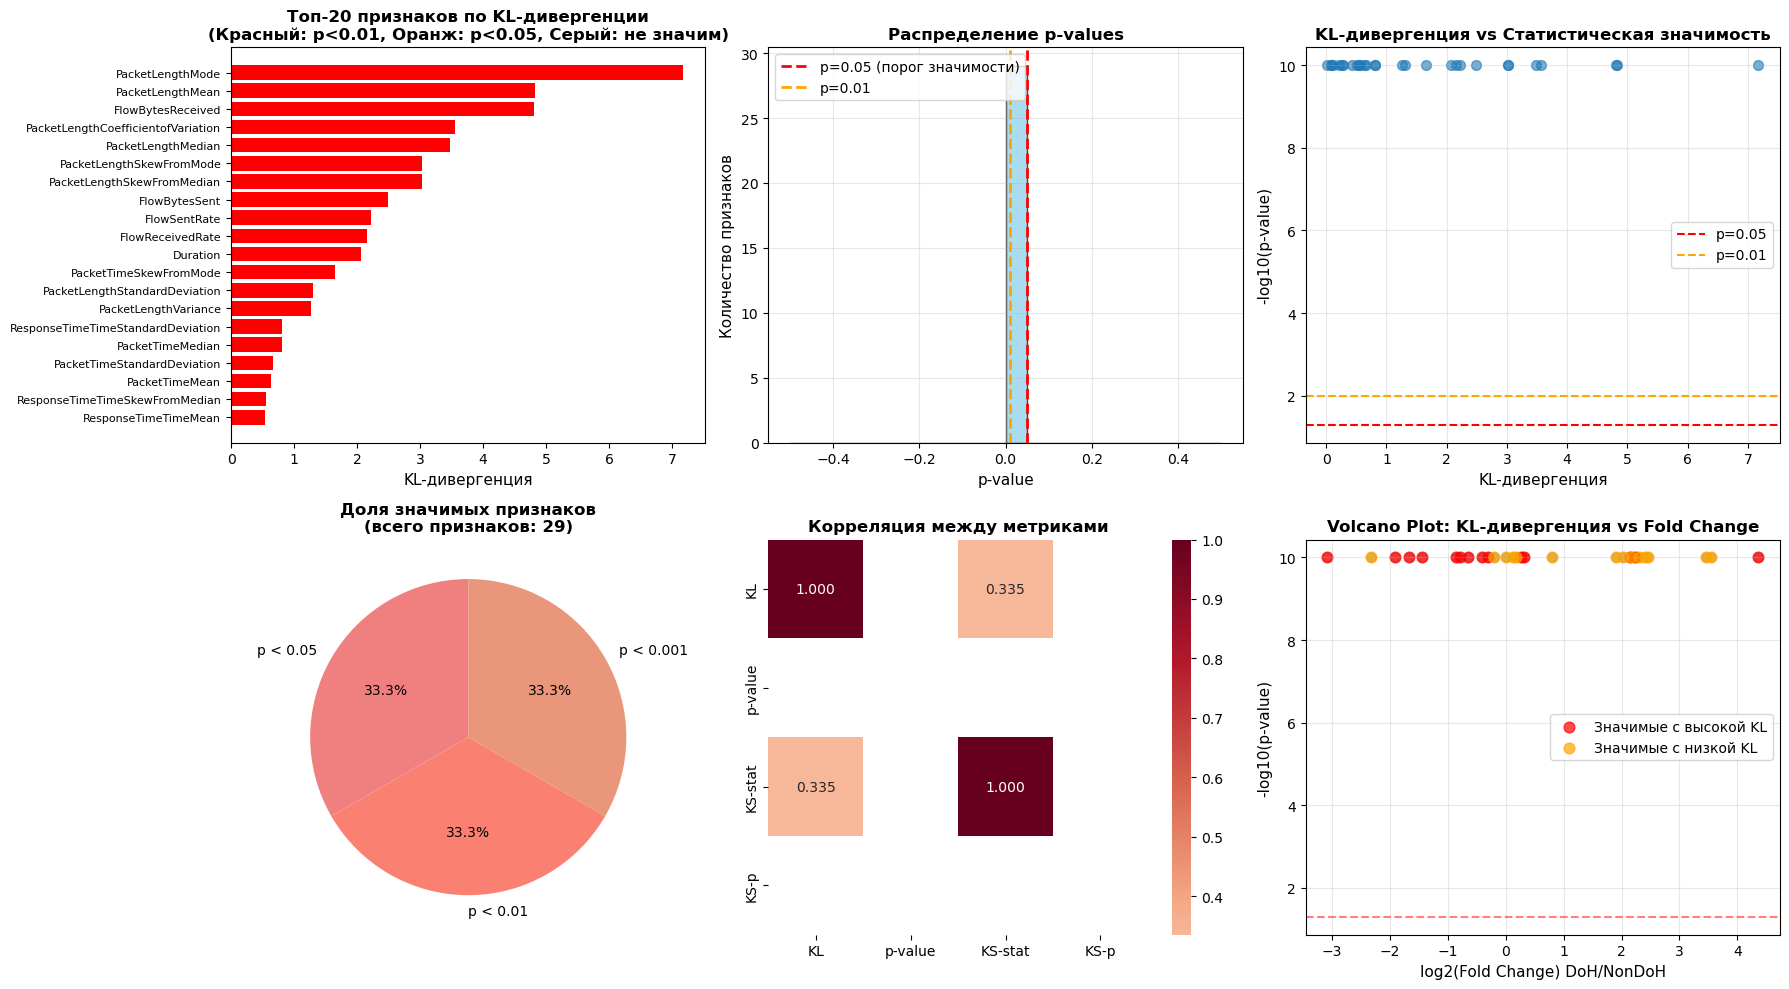

In [51]:
# Визуализация результатов
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. KL-дивергенция с цветовой кодировкой значимости
ax1 = axes[0, 0]
top20 = kl_stats_df.head(20)
colors = ['red' if p < 0.01 else 'orange' if p < 0.05 else 'gray' 
          for p in top20['p_value']]
ax1.barh(range(len(top20)), top20['kl_divergence'].values, color=colors)
ax1.set_yticks(range(len(top20)))
ax1.set_yticklabels(top20['feature'].values, fontsize=8)
ax1.set_xlabel('KL-дивергенция', fontsize=11)
ax1.set_title('Топ-20 признаков по KL-дивергенции\n(Красный: p<0.01, Оранж: p<0.05, Серый: не значим)', 
              fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# 2. Распределение p-values
ax2 = axes[0, 1]
ax2.hist(kl_stats_df['p_value'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='p=0.05 (порог значимости)')
ax2.axvline(x=0.01, color='orange', linestyle='--', linewidth=2, label='p=0.01')
ax2.set_xlabel('p-value', fontsize=11)
ax2.set_ylabel('Количество признаков', fontsize=11)
ax2.set_title('Распределение p-values', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Зависимость KL от p-value
ax3 = axes[0, 2]
ax3.scatter(kl_stats_df['kl_divergence'], -np.log10(kl_stats_df['p_value'] + 1e-10), 
           alpha=0.6, s=50)
ax3.axhline(y=-np.log10(0.05), color='red', linestyle='--', label='p=0.05')
ax3.axhline(y=-np.log10(0.01), color='orange', linestyle='--', label='p=0.01')
ax3.set_xlabel('KL-дивергенция', fontsize=11)
ax3.set_ylabel('-log10(p-value)', fontsize=11)
ax3.set_title('KL-дивергенция vs Статистическая значимость', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Доля значимых признаков
ax4 = axes[1, 0]
significant_counts = [len(kl_stats_df[kl_stats_df['p_value'] < 0.05]),
                      len(kl_stats_df[kl_stats_df['p_value'] < 0.01]),
                      len(kl_stats_df[kl_stats_df['p_value'] < 0.001])]
labels = ['p < 0.05', 'p < 0.01', 'p < 0.001']
colors_pie = ['lightcoral', 'salmon', 'darksalmon']
ax4.pie(significant_counts, labels=labels, colors=colors_pie, autopct='%1.1f%%',
        startangle=90)
ax4.set_title(f'Доля значимых признаков\n(всего признаков: {len(kl_stats_df)})', 
              fontsize=12, fontweight='bold')

# 5. Тепловая карта корреляции между KL и другими метриками
ax5 = axes[1, 1]
# Добавляем KS-тест для сравнения
ks_stats = []
for col in X.columns:
    p = X_doh[col].values
    q = X_nondoh[col].values
    ks_stat, ks_p = ks_2samp(p, q)
    ks_stats.append({'feature': col, 'ks_statistic': ks_stat, 'ks_pvalue': ks_p})

ks_df = pd.DataFrame(ks_stats)
comparison = kl_stats_df.merge(ks_df, on='feature')
corr_matrix = comparison[['kl_divergence', 'p_value', 'ks_statistic', 'ks_pvalue']].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            xticklabels=['KL', 'p-value', 'KS-stat', 'KS-p'], 
            yticklabels=['KL', 'p-value', 'KS-stat', 'KS-p'], ax=ax5)
ax5.set_title('Корреляция между метриками', fontsize=12, fontweight='bold')

# 6. Volcano plot (аналог из геномики)
ax6 = axes[1, 2]
# Добавляем fold change (отношение средних)
mean_ratio = []
for col in X.columns:
    mean_doh = X_doh[col].mean()
    mean_nondoh = X_nondoh[col].mean()
    if mean_nondoh != 0:
        ratio = np.log2(mean_doh / (mean_nondoh + 1e-10))
    else:
        ratio = 0
    mean_ratio.append(ratio)

kl_stats_df['log2_fold_change'] = mean_ratio
significant_high = kl_stats_df[(kl_stats_df['p_value'] < 0.05) & (kl_stats_df['kl_divergence'] > kl_stats_df['kl_divergence'].median())]
significant_low = kl_stats_df[(kl_stats_df['p_value'] < 0.05) & (kl_stats_df['kl_divergence'] <= kl_stats_df['kl_divergence'].median())]

ax6.scatter(kl_stats_df['log2_fold_change'], -np.log10(kl_stats_df['p_value'] + 1e-10), 
           alpha=0.5, s=40, c='gray')
ax6.scatter(significant_high['log2_fold_change'], -np.log10(significant_high['p_value'] + 1e-10), 
           alpha=0.7, s=60, c='red', label='Значимые с высокой KL')
ax6.scatter(significant_low['log2_fold_change'], -np.log10(significant_low['p_value'] + 1e-10), 
           alpha=0.7, s=60, c='orange', label='Значимые с низкой KL')
ax6.axhline(y=-np.log10(0.05), color='red', linestyle='--', alpha=0.5)
ax6.set_xlabel('log2(Fold Change) DoH/NonDoH', fontsize=11)
ax6.set_ylabel('-log10(p-value)', fontsize=11)
ax6.set_title('Volcano Plot: KL-дивергенция vs Fold Change', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("output_13.png", dpi=400)
plt.show()

In [52]:
# Детальный статистический отчет
print("\n" + "="*80)
print("СТАТИСТИЧЕСКИЙ ОТЧЕТ ПО KL-ДИВЕРГЕНЦИИ")
print("="*80)

# Общая статистика
print(f"\n1. ОБЩАЯ СТАТИСТИКА:")
print(f"   - Всего признаков: {len(kl_stats_df)}")
print(f"   - Признаков с KL > 0: {(kl_stats_df['kl_divergence'] > 0).sum()}")
print(f"   - Максимальная KL: {kl_stats_df['kl_divergence'].max():.6f} (признак: {kl_stats_df.iloc[0]['feature']})")
print(f"   - Минимальная KL: {kl_stats_df['kl_divergence'].min():.6f}")

# Значимость
print(f"\n2. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ:")
print(f"   - Значимые признаки (p < 0.05): {kl_stats_df['significant'].sum()} ({kl_stats_df['significant'].sum()/len(kl_stats_df)*100:.1f}%)")
print(f"   - Высоко значимые (p < 0.01): {kl_stats_df['highly_significant'].sum()} ({kl_stats_df['highly_significant'].sum()/len(kl_stats_df)*100:.1f}%)")
print(f"   - Среднее p-value: {kl_stats_df['p_value'].mean():.6f}")
print(f"   - Медианное p-value: {kl_stats_df['p_value'].median():.6f}")

# Топ-10 с деталями
print(f"\n3. ТОП-10 ПРИЗНАКОВ С ДЕТАЛИЗАЦИЕЙ:")
top10_detailed = kl_stats_df.head(10).copy()
top10_detailed['p_value_scientific'] = top10_detailed['p_value'].apply(lambda x: f'{x:.2e}')
top10_detailed['significance_stars'] = top10_detailed['p_value'].apply(
    lambda x: '***' if x < 0.001 else '**' if x < 0.01 else '*' if x < 0.05 else 'ns'
)
print(top10_detailed[['feature', 'kl_divergence', 'p_value_scientific', 'significance_stars']].to_string(index=False))

# Сохранение результатов
kl_stats_df.to_csv('kl_divergence_with_pvalues.csv', index=False)
print(f"\n4. Результаты сохранены в 'kl_divergence_with_pvalues.csv'")

# Создание сводной таблицы для публикации
summary_table = kl_stats_df[kl_stats_df['significant']].head(20)[
    ['feature', 'kl_divergence', 'p_value']
].copy()
summary_table['p_value'] = summary_table['p_value'].apply(lambda x: f'{x:.4f}')
summary_table['kl_divergence'] = summary_table['kl_divergence'].apply(lambda x: f'{x:.6f}')
summary_table['rank'] = range(1, len(summary_table)+1)
summary_table = summary_table[['rank', 'feature', 'kl_divergence', 'p_value']]

print("\n5. ТОП-20 ЗНАЧИМЫХ ПРИЗНАКОВ ДЛЯ ПУБЛИКАЦИИ:")
print(summary_table.to_string(index=False))


СТАТИСТИЧЕСКИЙ ОТЧЕТ ПО KL-ДИВЕРГЕНЦИИ

1. ОБЩАЯ СТАТИСТИКА:
   - Всего признаков: 29
   - Признаков с KL > 0: 29
   - Максимальная KL: 7.172411 (признак: PacketLengthMode)
   - Минимальная KL: 0.019225

2. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ:
   - Значимые признаки (p < 0.05): 29 (100.0%)
   - Высоко значимые (p < 0.01): 29 (100.0%)
   - Среднее p-value: 0.000000
   - Медианное p-value: 0.000000

3. ТОП-10 ПРИЗНАКОВ С ДЕТАЛИЗАЦИЕЙ:
                           feature  kl_divergence p_value_scientific significance_stars
                  PacketLengthMode       7.172411           0.00e+00                ***
                  PacketLengthMean       4.821473           0.00e+00                ***
                 FlowBytesReceived       4.816966           0.00e+00                ***
PacketLengthCoefficientofVariation       3.559075           0.00e+00                ***
                PacketLengthMedian       3.478933           0.00e+00                ***
          PacketLengthSkewFromMode       3.0

In [53]:
# Интерпретация результатов
print("\n" + "="*80)
print("ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")
print("="*80)

print("""
KL-дивергенция с p-value позволяет:

1. ОЦЕНИТЬ РАЗЛИЧИЯ В РАСПРЕДЕЛЕНИЯХ:
   - KL > 0.1: сильное различие между классами
   - 0.01 < KL < 0.1: умеренное различие
   - KL < 0.01: слабое различие

2. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ:
   - p < 0.001 (***): очень сильные доказательства различий
   - p < 0.01 (**): сильные доказательства различий
   - p < 0.05 (*): доказательства различий
   - p >= 0.05 (ns): нет статистически значимых различий

3. ПРАКТИЧЕСКАЯ ЗНАЧИМОСТЬ:
   - Высокая KL + низкое p-value: признак отлично разделяет классы
   - Низкая KL + низкое p-value: разделение есть, но слабое
   - Высокая KL + высокое p-value: редкий случай, требует проверки
""")

# Выявление лучших признаков для классификации
best_features = kl_stats_df[(kl_stats_df['kl_divergence'] > 0.05) & 
                            (kl_stats_df['p_value'] < 0.01)].head(10)

print("\nЛУЧШИЕ ПРИЗНАКИ ДЛЯ КЛАССИФИКАЦИИ (KL > 0.05 и p < 0.01):")
print(best_features[['feature', 'kl_divergence', 'p_value']].to_string(index=False))


ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ

KL-дивергенция с p-value позволяет:

1. ОЦЕНИТЬ РАЗЛИЧИЯ В РАСПРЕДЕЛЕНИЯХ:
   - KL > 0.1: сильное различие между классами
   - 0.01 < KL < 0.1: умеренное различие
   - KL < 0.01: слабое различие

2. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ:
   - p < 0.001 (***): очень сильные доказательства различий
   - p < 0.01 (**): сильные доказательства различий
   - p < 0.05 (*): доказательства различий
   - p >= 0.05 (ns): нет статистически значимых различий

3. ПРАКТИЧЕСКАЯ ЗНАЧИМОСТЬ:
   - Высокая KL + низкое p-value: признак отлично разделяет классы
   - Низкая KL + низкое p-value: разделение есть, но слабое
   - Высокая KL + высокое p-value: редкий случай, требует проверки


ЛУЧШИЕ ПРИЗНАКИ ДЛЯ КЛАССИФИКАЦИИ (KL > 0.05 и p < 0.01):
                           feature  kl_divergence  p_value
                  PacketLengthMode       7.172411      0.0
                  PacketLengthMean       4.821473      0.0
                 FlowBytesReceived       4.816966      0.0
PacketLengthCoe

### Тест Грейнджера

In [60]:
y = df_l1['Label_encoded']

In [61]:
from statsmodels.tsa.stattools import grangercausalitytests

# ВАЖНО: Для теста Грейнджера используем исходные данные ДО перемешивания.
# Предполагаем, что у вас есть исходный DataFrame 'df', где лежат признаки и целевая переменная 'target'
# Если у вас X и y разделены, но упорядочены, объединим их обратно:
df_time_series = X.copy()
df_time_series['target'] = y

# Переводим таргет в float для корректной работы библиотеки
df_time_series['target'] = df_time_series['target'].astype(float)

granger_results = []
lags = [1, 2, 3]

print("Запуск теста Грейнджера (это может занять некоторое время для 800к+ строк)...")

# Перебираем каждый признак (кроме самого таргета)
for feature in X.columns:
    # Проверяем, есть ли изменения в признаке (тест не работает с константами)
    if df_time_series[feature].nunique() <= 1:
        continue
        
    try:
        # statsmodels ожидает 2D-массив, где первый столбец — зависимая переменная (y), второй — предиктор (X)
        data_subset = df_time_series[['target', feature]].dropna()
        
        # Запускаем тест для лагов 1, 2, 3 без вывода логов в консоль (verbose=False)
        test_res = grangercausalitytests(data_subset, maxlag=3, verbose=False)
        
        row = {'Feature': feature}
        for lag in lags:
            # Берем p-value теста соотношения правдоподобия (lrtest) — он наиболее стабилен
            p_val = test_res[lag][0]['lrtest'][1]
            row[f'Lag_{lag}_p_value'] = p_val
            
        granger_results.append(row)
    except Exception as e:
        # Если возникла математическая ошибка (например, из-за сильной мультиколлинеарности)
        print(f"Ошибка при расчете признака {feature}: {e}")

# Оформляем результаты в таблицу
granger_df = pd.DataFrame(granger_results)

# Добавляем колонку-вывод: значим ли признак хотя бы на одном лаге (p-value < 0.05)
granger_df['Is_Significant'] = (granger_df['Lag_1_p_value'] < 0.05) | \
                               (granger_df['Lag_2_p_value'] < 0.05) | \
                               (granger_df['Lag_3_p_value'] < 0.05)

# Сортируем: сначала самые значимые (с наименьшим p-value на 1-м лаге)
granger_df = granger_df.sort_values(by='Lag_1_p_value').reset_index(drop=True)

print("\nРезультаты теста причинности Грейнджера (первые 10 признаков):")
print(granger_df.head(10))

Запуск теста Грейнджера (это может занять некоторое время для 800к+ строк)...

Результаты теста причинности Грейнджера (первые 10 признаков):
                                  Feature  Lag_1_p_value  Lag_2_p_value  \
0                      PacketTimeVariance       0.374933       0.002959   
1                PacketTimeSkewFromMedian       0.425160       0.727579   
2                                Duration       0.452302       0.000143   
3      PacketLengthCoefficientofVariation       0.458704       0.754291   
4  ResponseTimeTimeCoefficientofVariation       0.459707       0.638687   
5             PacketTimeStandardDeviation       0.524224       0.003194   
6        PacketTimeCoefficientofVariation       0.544570       0.706458   
7                          PacketTimeMean       0.587739       0.000219   
8           PacketLengthStandardDeviation       0.644227       0.876549   
9                    ResponseTimeTimeMean       0.667803       0.850623   

   Lag_3_p_value  Is_Significant

In [62]:
granger_df.head(29)

,Feature,Lag_1_p_value,Lag_2_p_value,Lag_3_p_value,Is_Significant
0,PacketTimeVariance,0.374933,0.002959,9.221705e-04,True
1,PacketTimeSkewFromMedian,0.425160,0.727579,8.662183e-01,False
2,Duration,0.452302,0.000143,5.507530e-05,True
3,PacketLengthCoefficientofVariation,0.458704,0.754291,8.831344e-01,False
4,ResponseTimeTimeCoefficientofVariation,0.459707,0.638687,9.190036e-07,True
5,PacketTimeStandardDeviation,0.524224,0.003194,1.721757e-03,True
6,PacketTimeCoefficientofVariation,0.544570,0.706458,8.520082e-01,False
7,PacketTimeMean,0.587739,0.000219,1.293598e-04,True
8,PacketLengthStandardDeviation,0.644227,0.876549,9.583819e-01,False
9,ResponseTimeTimeMean,0.667803,0.850623,9.374795e-01,False


### Полный код для теста Грейнджера (расширенный). Внимание! Требует много ресурсов, сложность $O(n^2\cdot( max(lag))\cdot(m))$

In [64]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.tsa.api import VAR
import itertools
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from tqdm import tqdm  # Импортируем tqdm

# 1. Подготовка данных для теста Грейнджера
print("=== ПОДГОТОВКА ДАННЫХ ДЛЯ ТЕСТА ГРЕЙНДЖЕРА ===\n")

# Загрузка данных
df = pd.read_parquet('L1-DoH-NonDoH.parquet')
X = df.drop('Label', axis=1)
y = df['Label']

# Выбираем топ-10 признаков по KL-дивергенции для анализа
top_features = kl_stats_df.head(10)['feature'].tolist()
print(f"Анализируемые признаки: {top_features}")

# Для теста Грейнджера нужен временной порядок
# Используем индекс как время (предполагаем, что данные упорядочены)
df_temp = df[top_features].copy()

# Стандартизация (важно для VAR модели)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_temp),
                         columns=top_features,
                         index=df_temp.index)

# Добавляем целевую переменную (DoH/NonDoH как бинарную)
df_scaled['is_doh'] = (y == 'DoH').astype(int)

# 2. Проверка стационарности (необходимое условие)
print("\n=== ПРОВЕРКА СТАЦИОНАРНОСТИ ===")

def check_stationarity(series, column_name, significance=0.05):
    """Тест Дики-Фуллера на стационарность"""
    result = adfuller(series.dropna())
    p_value = result[1]
    is_stationary = p_value < significance
    return is_stationary, p_value

# Прогресс-бар для проверки стационарности
stationarity_results = []
for col in tqdm(df_scaled.columns, desc="Проверка стационарности"):
    is_stationary, p_val = check_stationarity(df_scaled[col], col)
    stationarity_results.append({
        'feature': col,
        'is_stationary': is_stationary,
        'p_value': p_val
    })

stationarity_df = pd.DataFrame(stationarity_results)
print(stationarity_df.to_string(index=False))

# Для нестационарных рядов применяем дифференцирование
print("\nПрименяем дифференцирование для нестационарных рядов...")
non_stationary_cols = stationarity_df[~stationarity_df['is_stationary']]['feature'].tolist()
for col in tqdm(non_stationary_cols, desc="Дифференцирование рядов"):
    df_diff[col] = df_scaled[col].diff().fillna(0)
    # Проверяем после дифференцирования
    is_stationary, _ = check_stationarity(df_diff[col], col)
    print(f"  {col}: после дифференцирования {'стационарен' if is_stationary else 'не стационарен'}")

# 3. Тест Грейнджера на каузальность с ПРОГРЕСС-БАРОМ
print("\n=== ТЕСТ ГРЕЙНДЖЕРА НА ПРИЧИННО-СЛЕДСТВЕННЫЕ СВЯЗИ ===")

def granger_causality_matrix(data, features, maxlag=5, significance=0.05):
    """
    Создание матрицы Грейнджер-каузальности с прогресс-баром
    Возвращает: матрицу p-values и силу связи (-log10(p-value))
    """
    n = len(features)
    pvalue_matrix = np.zeros((n, n))
    strength_matrix = np.zeros((n, n))
    
    # Общее количество итераций
    total_iterations = n * (n - 1)
    
    # Создаем прогресс-бар
    with tqdm(total=total_iterations, desc="Расчет Грейнджер-каузальности", 
              unit="пар", ncols=80) as pbar:
        
        for i, j in itertools.product(range(n), range(n)):
            if i != j:
                try:
                    # Тест Грейнджера
                    test_result = grangercausalitytests(
                        data[[features[i], features[j]]], 
                        maxlag=maxlag, 
                        verbose=False
                    )
                    
                    # Берем лучшее p-value среди всех лагов
                    p_values = [test_result[lag][0]['ssr_ftest'][1] for lag in range(1, maxlag+1)]
                    min_p = np.min(p_values)
                    best_lag = np.argmin(p_values) + 1
                    
                    pvalue_matrix[i, j] = min_p
                    # Сила связи: -log10(p-value), но ограничиваем сверху
                    strength_matrix[i, j] = min(-np.log10(min_p), 10) if min_p > 0 else 10
                    
                except Exception as e:
                    pvalue_matrix[i, j] = 1.0
                    strength_matrix[i, j] = 0
                
                # Обновляем прогресс-бар
                pbar.update(1)
            else:
                # Для диагональных элементов не считаем
                pvalue_matrix[i, j] = 1.0
                strength_matrix[i, j] = 0
                
    return pvalue_matrix, strength_matrix

# Расчет матрицы каузальности с прогресс-баром
print("Расчет матрицы Грейнджер-каузальности...")
pvalue_matrix, strength_matrix = granger_causality_matrix(
    df_diff[top_features], top_features, maxlag=3, significance=0.05
)

# Создание DataFrame для визуализации
granger_df = pd.DataFrame(strength_matrix, index=top_features, columns=top_features)

# 4. Визуализация результатов (остается без изменений)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 4.1 Тепловая карта силы связей
ax1 = axes[0]
mask = np.triu(np.ones_like(granger_df, dtype=bool), k=1)
im1 = sns.heatmap(granger_df, annot=True, fmt='.2f', cmap='RdYlGn_r',
                  xticklabels=top_features, yticklabels=top_features,
                  mask=mask, ax=ax1, square=True,
                  cbar_kws={'label': '-log10(p-value) - сила связи'})
ax1.set_title('Грейнджер-каузальность между признаками\n(Строка → Столбец)', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Целевой признак (Y)', fontsize=10)
ax1.set_ylabel('Причина (X)', fontsize=10)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4.2 Граф связей (только значимые, p < 0.05)
ax2 = axes[1]
significant_pairs = []
for i, row in enumerate(top_features):
    for j, col in enumerate(top_features):
        if i != j and pvalue_matrix[i, j] < 0.05:
            significant_pairs.append({
                'cause': row,
                'effect': col,
                'strength': strength_matrix[i, j],
                'p_value': pvalue_matrix[i, j]
            })

significant_df = pd.DataFrame(significant_pairs)
if len(significant_df) > 0:
    significant_df = significant_df.sort_values('strength', ascending=False)
    
    # Создаем граф
    pos = {feature: (np.random.rand()*2-1, np.random.rand()*2-1) for feature in top_features}
    
    # Рисуем узлы
    for feature in top_features:
        ax2.scatter(pos[feature][0], pos[feature][1], s=500, c='lightblue', 
                   edgecolors='black', linewidth=2, zorder=3)
        ax2.annotate(feature, (pos[feature][0], pos[feature][1]), 
                    ha='center', va='center', fontsize=8, fontweight='bold')
    
    # Рисуем связи
    for _, edge in significant_df.head(10).iterrows():
        start = pos[edge['cause']]
        end = pos[edge['effect']]
        # Сила связи определяет толщину линии
        width = edge['strength'] / 5
        ax2.annotate("", xy=end, xytext=start,
                    arrowprops=dict(arrowstyle="->", lw=width, 
                                  color='red' if edge['strength'] > 3 else 'orange',
                                  alpha=min(0.8, edge['strength']/5)))
    
    ax2.set_title(f'Граф значимых связей (p < 0.05)\nПоказано топ-10', 
                 fontsize=12, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'Нет значимых связей\n(p < 0.05)', 
            ha='center', va='center', transform=ax2.transAxes)
ax2.set_xlim(-1.5, 1.5)
ax2.set_ylim(-1.5, 1.5)
ax2.axis('off')

# 4.3 Распределение p-values
ax3 = axes[2]
p_values_flat = pvalue_matrix[pvalue_matrix != 0]
ax3.hist(p_values_flat, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax3.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='p = 0.05 (порог)')
ax3.axvline(x=0.01, color='orange', linestyle='--', linewidth=2, label='p = 0.01')
ax3.set_xlabel('p-value', fontsize=11)
ax3.set_ylabel('Количество пар', fontsize=11)
ax3.set_title('Распределение p-values теста Грейнджера', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Детальный отчет о значимых связях
print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ ТЕСТА ГРЕЙНДЖЕРА")
print("="*80)

print(f"\nВсего проверено пар: {len(top_features) * (len(top_features)-1)}")
print(f"Статистически значимых связей (p < 0.05): {len(significant_df)}")
print(f"Очень сильных связей (p < 0.01): {len(significant_df[significant_df['p_value'] < 0.01])}")

if len(significant_df) > 0:
    print("\n=== ТОП-10 САМЫХ СИЛЬНЫХ ПРИЧИННО-СЛЕДСТВЕННЫХ СВЯЗЕЙ ===")
    top_causal = significant_df.head(10)
    for idx, row in top_causal.iterrows():
        print(f"{row['cause']} → {row['effect']}: "
              f"p = {row['p_value']:.6f}, "
              f"сила = {row['strength']:.3f} (-log10(p))")

=== ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ===
Сэмплировано до 3000 строк для ускорения

=== ПРОВЕРКА СТАЦИОНАРНОСТИ (параллельно) ===
                           feature  is_stationary      p_value
                  PacketLengthMode           True 6.194001e-08
                  PacketLengthMean           True 5.427728e-08
                 FlowBytesReceived           True 2.803275e-27
PacketLengthCoefficientofVariation           True 1.017273e-10
                PacketLengthMedian           True 1.175506e-13
          PacketLengthSkewFromMode           True 0.000000e+00
        PacketLengthSkewFromMedian           True 0.000000e+00
                     FlowBytesSent           True 2.372811e-07
                      FlowSentRate           True 0.000000e+00
                  FlowReceivedRate           True 0.000000e+00

=== ОПТИМИЗИРОВАННЫЙ ТЕСТ ГРЕЙНДЖЕРА ===
Расчет каузальности...


Тест Грейнджера: 100%|███████████████████████████████████████████████████████████████| 90/90 [00:00<00:00, 3332.60it/s]
